<a href="https://colab.research.google.com/github/jamiroquai1225/Forecasting/blob/main/jeju_port_cargo_forecasting_using_bsi_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 초기 TEST

제주항 화물량 예측 시스템

[1단계] 데이터 로드 중...
BSI 데이터: (116, 5)
PORT 데이터: (115, 3)

병합된 데이터: (115, 7)
기간: 2016-01-01 00:00:00 ~ 2025-07-01 00:00:00

[2단계] 데이터 분할 중...
Train 데이터: 103개월 (2016-01-01 00:00:00 ~ 2024-07-01 00:00:00)
Test 데이터: 12개월 (2024-08-01 00:00:00 ~ 2025-07-01 00:00:00)

[3단계] SARIMA 모델 학습 중...
최적 SARIMA 파라미터 탐색 중... (약 1-2분 소요)
최적 파라미터: order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)
SARIMA 모델 완료!

[4단계] SARIMAX 모델 학습 중...
SARIMAX 모델 완료!

[5단계] Prophet 모델 학습 중...


17:04:58 - cmdstanpy - INFO - Chain [1] start processing
17:04:59 - cmdstanpy - INFO - Chain [1] done processing
17:04:59 - cmdstanpy - INFO - Chain [1] start processing
17:04:59 - cmdstanpy - INFO - Chain [1] done processing


Prophet 모델 완료!

[6단계] Prophet + 외생변수 모델 학습 중...
Prophet + 외생변수 모델 완료!

모델 성능 평가

1. SARIMA
--------------------------------------------------
MAE:  83,464.55 톤
RMSE: 100,484.92 톤
MAPE: 4.83%
R²:   0.5028

2. SARIMAX (BSI 포함)
--------------------------------------------------
MAE:  72,383.07 톤
RMSE: 98,409.93 톤
MAPE: 4.06%
R²:   0.5231

3. Prophet (기본)
--------------------------------------------------
MAE:  68,506.14 톤
RMSE: 86,172.34 톤
MAPE: 3.79%
R²:   0.6343

4. Prophet + BSI
--------------------------------------------------
MAE:  104,789.08 톤
RMSE: 126,645.96 톤
MAPE: 5.75%
R²:   0.2102

[7단계] 결과 시각화 중...
그래프 저장 완료: C:\Users\DAEJIN\Desktop/제주항_화물량_예측결과.png

[8단계] 결과 저장 중...
예측 결과 저장 완료: C:\Users\DAEJIN\Desktop/제주항_예측결과.xlsx
평가 지표 저장 완료: C:\Users\DAEJIN\Desktop/모델_평가지표.xlsx

[9단계] 미래 12개월 예측 중...
미래 예측 저장 완료: C:\Users\DAEJIN\Desktop/미래_12개월_예측.xlsx

모든 작업 완료!

생성된 파일:
1. C:\Users\DAEJIN\Desktop/제주항_화물량_예측결과.png
2. C:\Users\DAEJIN\Desktop/제주항_예측결과.xlsx
3. C:\Users\DAEJIN\Desktop/모델_평

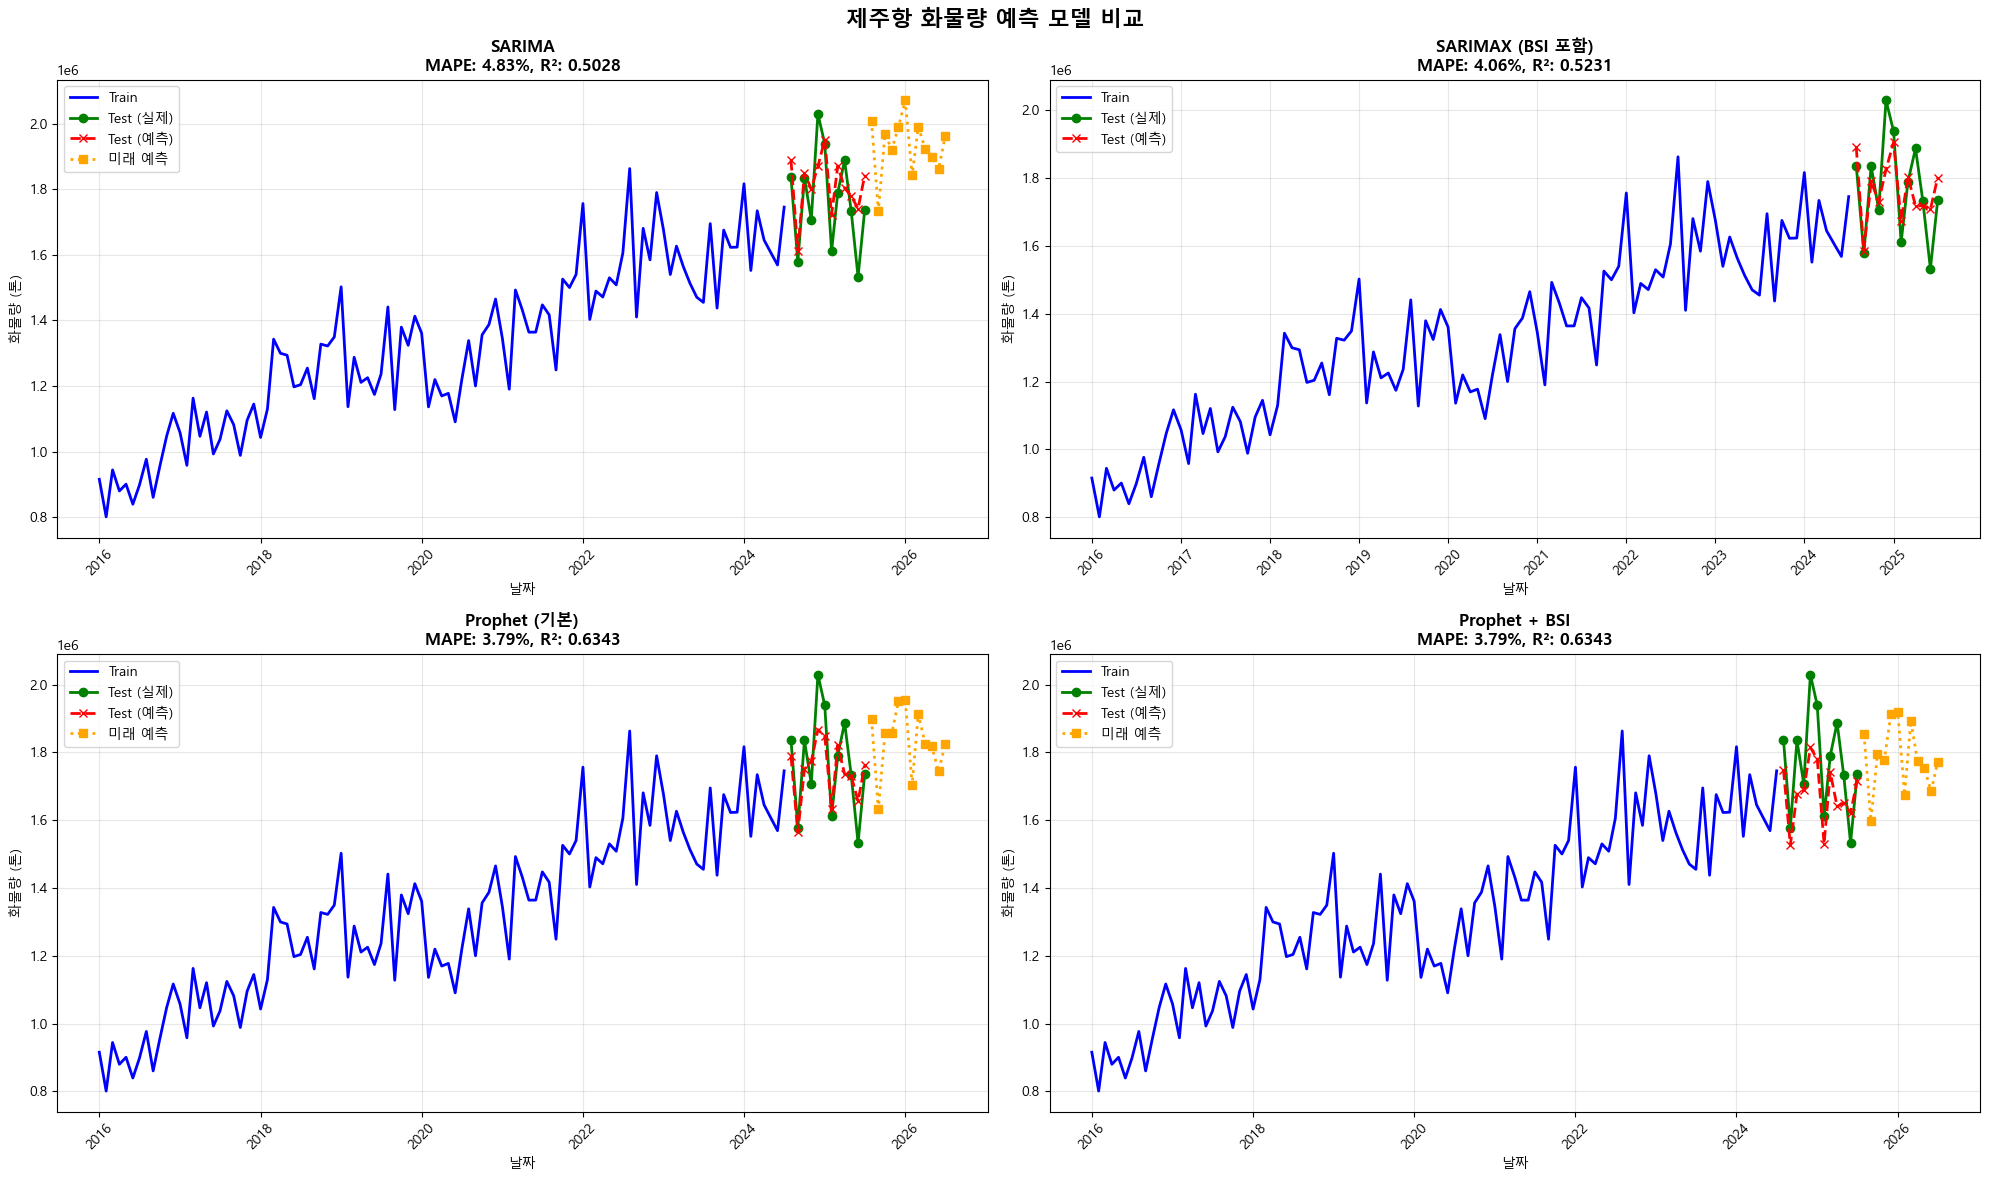

In [ ]:
"""
제주항 화물량 예측 모델
- SARIMA
- SARIMAX (BSI 외생변수 포함)
- Prophet (기본)
- Prophet (BSI 외생변수 포함)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

# 필요한 라이브러리
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import itertools

print("=" * 80)
print("제주항 화물량 예측 시스템")
print("=" * 80)

# ========================================
# 1. 데이터 로드 및 전처리
# ========================================
print("\n[1단계] 데이터 로드 중...")

# 데이터 경로 (사용자 데스크탑)
DATA_PATH = r'C:\Users\DAEJIN\Desktop'

# 데이터 읽기
bsi_df = pd.read_excel(f'{DATA_PATH}/bsi data.xlsx')
port_df = pd.read_excel(f'{DATA_PATH}/port data.xlsx')

print(f"BSI 데이터: {bsi_df.shape}")
print(f"PORT 데이터: {port_df.shape}")

# year 컬럼 정수로 변환
bsi_df['year'] = bsi_df['year'].astype(int)
port_df['year'] = port_df['year'].astype(int)

# 날짜 컬럼 생성
bsi_df['date'] = pd.to_datetime(bsi_df['year'].astype(str) + '-' + bsi_df['month'].astype(str) + '-01')
port_df['date'] = pd.to_datetime(port_df['year'].astype(str) + '-' + port_df['month'].astype(str) + '-01')

# 데이터 병합 (port 데이터 기준)
df = port_df.merge(bsi_df[['date', '제조업 기업심리지수실적', '제조업 업황BSI', '제조업 매출BSI']],
                   on='date', how='left')

print(f"\n병합된 데이터: {df.shape}")
print(f"기간: {df['date'].min()} ~ {df['date'].max()}")

# ========================================
# 2. Train/Test 분할
# ========================================
print("\n[2단계] 데이터 분할 중...")

# 마지막 12개월을 테스트 데이터로 사용
TEST_MONTHS = 12
FORECAST_MONTHS = 12  # 미래 예측 개월 수

train_df = df.iloc[:-TEST_MONTHS].copy()
test_df = df.iloc[-TEST_MONTHS:].copy()

print(f"Train 데이터: {len(train_df)}개월 ({train_df['date'].min()} ~ {train_df['date'].max()})")
print(f"Test 데이터: {len(test_df)}개월 ({test_df['date'].min()} ~ {test_df['date'].max()})")

# ========================================
# 3. 모델 1: SARIMA
# ========================================
print("\n[3단계] SARIMA 모델 학습 중...")

# SARIMA 파라미터 (월별 데이터이므로 계절성 주기 = 12)
# 자동으로 최적 파라미터 찾기 (시간이 오래 걸릴 수 있음)
print("최적 SARIMA 파라미터 탐색 중... (약 1-2분 소요)")

# 간단한 그리드 서치
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

best_aic = np.inf
best_param = None
best_seasonal_param = None

for param in pdq[:5]:  # 시간 절약을 위해 일부만 테스트
    for seasonal_param in seasonal_pdq[:5]:
        try:
            model = SARIMAX(train_df['화물량'],
                          order=param,
                          seasonal_order=seasonal_param,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            results = model.fit(disp=False)

            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_seasonal_param = seasonal_param
        except:
            continue

print(f"최적 파라미터: order={best_param}, seasonal_order={best_seasonal_param}")

# 최적 파라미터로 모델 학습
sarima_model = SARIMAX(train_df['화물량'],
                       order=best_param if best_param else (1, 1, 1),
                       seasonal_order=best_seasonal_param if best_seasonal_param else (1, 1, 1, 12))
sarima_results = sarima_model.fit(disp=False)

# 예측
sarima_forecast = sarima_results.forecast(steps=TEST_MONTHS)
sarima_future = sarima_results.forecast(steps=TEST_MONTHS + FORECAST_MONTHS)

print("SARIMA 모델 완료!")

# ========================================
# 4. 모델 2: SARIMAX (외생변수 포함)
# ========================================
print("\n[4단계] SARIMAX 모델 학습 중...")

# 외생변수: BSI 지수들
exog_cols = ['제조업 기업심리지수실적', '제조업 업황BSI', '제조업 매출BSI']

# SARIMAX 모델
sarimax_model = SARIMAX(train_df['화물량'],
                        exog=train_df[exog_cols],
                        order=best_param if best_param else (1, 1, 1),
                        seasonal_order=best_seasonal_param if best_seasonal_param else (1, 1, 1, 12))
sarimax_results = sarimax_model.fit(disp=False)

# 예측 (외생변수 필요)
sarimax_forecast = sarimax_results.forecast(steps=TEST_MONTHS, exog=test_df[exog_cols])

print("SARIMAX 모델 완료!")

# ========================================
# 5. 모델 3: Prophet (기본)
# ========================================
print("\n[5단계] Prophet 모델 학습 중...")

# Prophet용 데이터 포맷
prophet_train = train_df[['date', '화물량']].copy()
prophet_train.columns = ['ds', 'y']

# Prophet 모델
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
prophet_model.fit(prophet_train)

# 예측
future = prophet_model.make_future_dataframe(periods=TEST_MONTHS + FORECAST_MONTHS, freq='MS')
prophet_forecast_full = prophet_model.predict(future)

# 테스트 기간 예측값 추출
prophet_forecast = prophet_forecast_full.iloc[-TEST_MONTHS-FORECAST_MONTHS:-FORECAST_MONTHS]['yhat'].values

print("Prophet 모델 완료!")

# ========================================
# 6. 모델 4: Prophet (외생변수 포함)
# ========================================
print("\n[6단계] Prophet + 외생변수 모델 학습 중...")

# Prophet용 데이터 (외생변수 추가)
prophet_train_exog = train_df[['date', '화물량'] + exog_cols].copy()
prophet_train_exog.columns = ['ds', 'y'] + exog_cols

# Prophet 모델 (외생변수 추가)
prophet_exog_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

# 외생변수를 regressor로 추가
for col in exog_cols:
    prophet_exog_model.add_regressor(col)

prophet_exog_model.fit(prophet_train_exog)

# 예측용 데이터프레임 생성
future_exog = prophet_model.make_future_dataframe(periods=TEST_MONTHS + FORECAST_MONTHS, freq='MS')

# 전체 데이터에서 외생변수 병합
full_df = pd.concat([train_df, test_df], ignore_index=True)
future_exog = future_exog.merge(full_df[['date'] + exog_cols], left_on='ds', right_on='date', how='left')

# 미래 외생변수는 마지막 값으로 채우기 (또는 별도 예측)
for col in exog_cols:
    future_exog[col].fillna(method='ffill', inplace=True)

prophet_exog_forecast_full = prophet_exog_model.predict(future_exog)
prophet_exog_forecast = prophet_exog_forecast_full.iloc[-TEST_MONTHS-FORECAST_MONTHS:-FORECAST_MONTHS]['yhat'].values

print("Prophet + 외생변수 모델 완료!")

# ========================================
# 7. 모델 평가
# ========================================
print("\n" + "=" * 80)
print("모델 성능 평가")
print("=" * 80)

actual = test_df['화물량'].values

def evaluate_model(name, predictions, actual):
    mae = mean_absolute_error(actual, predictions)
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    r2 = r2_score(actual, predictions)

    print(f"\n{name}")
    print("-" * 50)
    print(f"MAE:  {mae:,.2f} 톤")
    print(f"RMSE: {rmse:,.2f} 톤")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²:   {r2:.4f}")

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

results = {}
results['SARIMA'] = evaluate_model("1. SARIMA", sarima_forecast.values, actual)
results['SARIMAX'] = evaluate_model("2. SARIMAX (BSI 포함)", sarimax_forecast.values, actual)
results['Prophet'] = evaluate_model("3. Prophet (기본)", prophet_forecast, actual)
results['Prophet+BSI'] = evaluate_model("4. Prophet + BSI", prophet_exog_forecast, actual)

# ========================================
# 8. 시각화
# ========================================
print("\n[7단계] 결과 시각화 중...")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('제주항 화물량 예측 모델 비교', fontsize=16, fontweight='bold')

models = [
    ('SARIMA', sarima_forecast.values, sarima_future.values[-FORECAST_MONTHS:]),
    ('SARIMAX (BSI 포함)', sarimax_forecast.values, None),
    ('Prophet (기본)', prophet_forecast, prophet_forecast_full.iloc[-FORECAST_MONTHS:]['yhat'].values),
    ('Prophet + BSI', prophet_exog_forecast, prophet_exog_forecast_full.iloc[-FORECAST_MONTHS:]['yhat'].values)
]

for idx, (name, test_pred, future_pred) in enumerate(models):
    ax = axes[idx // 2, idx % 2]

    # Train 데이터
    ax.plot(train_df['date'], train_df['화물량'], label='Train', color='blue', linewidth=2)

    # Test 데이터 (실제값)
    ax.plot(test_df['date'], test_df['화물량'], label='Test (실제)', color='green', linewidth=2, marker='o')

    # Test 예측값
    ax.plot(test_df['date'], test_pred, label='Test (예측)', color='red', linewidth=2, linestyle='--', marker='x')

    # 미래 예측 (가능한 경우)
    if future_pred is not None:
        future_dates = pd.date_range(start=test_df['date'].iloc[-1] + pd.DateOffset(months=1),
                                     periods=FORECAST_MONTHS, freq='MS')
        ax.plot(future_dates, future_pred, label='미래 예측', color='orange', linewidth=2, linestyle=':', marker='s')

    ax.set_title(f'{name}\nMAPE: {results[name.split(" ")[0]]["MAPE"]:.2f}%, R²: {results[name.split(" ")[0]]["R2"]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('날짜', fontsize=10)
    ax.set_ylabel('화물량 (톤)', fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/제주항_화물량_예측결과.png', dpi=300, bbox_inches='tight')
print(f"그래프 저장 완료: {DATA_PATH}/제주항_화물량_예측결과.png")

# ========================================
# 9. 결과 저장
# ========================================
print("\n[8단계] 결과 저장 중...")

# 예측 결과 데이터프레임
results_df = pd.DataFrame({
    '날짜': test_df['date'],
    '실제_화물량': test_df['화물량'].values,
    'SARIMA_예측': sarima_forecast.values,
    'SARIMAX_예측': sarimax_forecast.values,
    'Prophet_예측': prophet_forecast,
    'Prophet_BSI_예측': prophet_exog_forecast
})

# 오차 계산
for model in ['SARIMA', 'SARIMAX', 'Prophet', 'Prophet_BSI']:
    results_df[f'{model}_오차'] = results_df['실제_화물량'] - results_df[f'{model}_예측']
    results_df[f'{model}_오차율(%)'] = (results_df[f'{model}_오차'] / results_df['실제_화물량'] * 100).round(2)

results_df.to_excel(f'{DATA_PATH}/제주항_예측결과.xlsx', index=False)
print(f"예측 결과 저장 완료: {DATA_PATH}/제주항_예측결과.xlsx")

# 모델 평가 지표 저장
metrics_df = pd.DataFrame(results).T
metrics_df.to_excel(f'{DATA_PATH}/모델_평가지표.xlsx')
print(f"평가 지표 저장 완료: {DATA_PATH}/모델_평가지표.xlsx")

# ========================================
# 10. 미래 예측 (2025년 8월 ~ 2026년 7월)
# ========================================
print("\n[9단계] 미래 12개월 예측 중...")

future_dates = pd.date_range(start=test_df['date'].iloc[-1] + pd.DateOffset(months=1),
                             periods=FORECAST_MONTHS, freq='MS')

future_results_df = pd.DataFrame({
    '날짜': future_dates,
    'SARIMA_예측': sarima_future.values[-FORECAST_MONTHS:],
    'Prophet_예측': prophet_forecast_full.iloc[-FORECAST_MONTHS:]['yhat'].values,
    'Prophet_BSI_예측': prophet_exog_forecast_full.iloc[-FORECAST_MONTHS:]['yhat'].values
})

future_results_df.to_excel(f'{DATA_PATH}/미래_12개월_예측.xlsx', index=False)
print(f"미래 예측 저장 완료: {DATA_PATH}/미래_12개월_예측.xlsx")

print("\n" + "=" * 80)
print("모든 작업 완료!")
print("=" * 80)
print(f"\n생성된 파일:")
print(f"1. {DATA_PATH}/제주항_화물량_예측결과.png")
print(f"2. {DATA_PATH}/제주항_예측결과.xlsx")
print(f"3. {DATA_PATH}/모델_평가지표.xlsx")
print(f"4. {DATA_PATH}/미래_12개월_예측.xlsx")
print("\n" + "=" * 80)

# 최종 요약
print("\n📊 모델 성능 순위 (MAPE 기준)")
print("-" * 50)
sorted_models = sorted(results.items(), key=lambda x: x[1]['MAPE'])
for rank, (model, metrics) in enumerate(sorted_models, 1):
    print(f"{rank}. {model}: MAPE {metrics['MAPE']:.2f}%, R² {metrics['R2']:.4f}")

# BSI 조합별 비교

제주항 화물량 예측 시스템 - BSI 조합별 분석

[1단계] 데이터 로드 중...
BSI 데이터: (116, 5)
PORT 데이터: (115, 3)

병합된 데이터: (115, 7)
기간: 2016-01-01 00:00:00 ~ 2025-07-01 00:00:00

[2단계] BSI 조합 생성 중...
총 7가지 BSI 조합:
  1. 기업심리
  2. 업황
  3. 매출
  4. 기업심리+업황
  5. 기업심리+매출
  6. 업황+매출
  7. 기업심리+업황+매출

[3단계] 데이터 분할 중...
Train 데이터: 103개월 (2016-01-01 00:00:00 ~ 2024-07-01 00:00:00)
Test 데이터: 12개월 (2024-08-01 00:00:00 ~ 2025-07-01 00:00:00)

[4단계] 기준 모델 학습 중...
  - SARIMA (외생변수 없음)
  - Prophet (외생변수 없음)

최적 SARIMA 파라미터 탐색 중...


17:10:21 - cmdstanpy - INFO - Chain [1] start processing
17:10:21 - cmdstanpy - INFO - Chain [1] done processing


최적 파라미터: order=(0, 1, 1), seasonal_order=(0, 0, 1, 12)

기준 모델 성능:
SARIMA  - MAPE: 6.38%, R²: -0.0645
Prophet - MAPE: 3.79%, R²: 0.6343

[5단계] BSI 조합별 모델 학습 중...

진행 중: 1/7 - 기업심리


17:10:22 - cmdstanpy - INFO - Chain [1] start processing
17:10:22 - cmdstanpy - INFO - Chain [1] done processing
17:10:22 - cmdstanpy - INFO - Chain [1] start processing
17:10:22 - cmdstanpy - INFO - Chain [1] done processing


  SARIMAX - MAPE: 6.31%, R²: -0.0383
  Prophet - MAPE: 5.66%, R²: 0.2306

진행 중: 2/7 - 업황
  SARIMAX - MAPE: 7.17%, R²: -0.3101
  Prophet - MAPE: 5.24%, R²: 0.2855

진행 중: 3/7 - 매출


...

  SARIMAX - MAPE: 6.10%, R²: 0.0664
  Prophet - MAPE: 4.99%, R²: 0.3300

진행 중: 4/7 - 기업심리+업황


17:10:22 - cmdstanpy - INFO - Chain [1] start processing
17:10:22 - cmdstanpy - INFO - Chain [1] done processing


  SARIMAX - MAPE: 7.38%, R²: -0.2993
  Prophet - MAPE: 5.69%, R²: 0.2237

진행 중: 5/7 - 기업심리+매출
  SARIMAX - MAPE: 6.26%, R²: -0.0048
  Prophet - MAPE: 5.64%, R²: 0.2333

진행 중: 6/7 - 업황+매출


17:10:22 - cmdstanpy - INFO - Chain [1] start processing
17:10:22 - cmdstanpy - INFO - Chain [1] done processing
17:10:23 - cmdstanpy - INFO - Chain [1] start processing
17:10:23 - cmdstanpy - INFO - Chain [1] done processing


  SARIMAX - MAPE: 7.55%, R²: -0.3655
  Prophet - MAPE: 5.73%, R²: 0.1871

진행 중: 7/7 - 기업심리+업황+매출
  SARIMAX - MAPE: 7.55%, R²: -0.3457
  Prophet - MAPE: 5.75%, R²: 0.2102

[6단계] 결과 정리 중...

BSI 조합별 성능 비교 결과

📊 SARIMAX 모델 순위 (MAPE 기준)
--------------------------------------------------------------------------------
순위   BSI 조합               MAPE       R²         개선율       
--------------------------------------------------------------------------------
1    매출                       6.10%    0.0664     4.31%
2    기업심리+매출                  6.26%   -0.0048     1.80%
3    기업심리                     6.31%   -0.0383     1.09%
4    없음 (기준)                  6.38%   -0.0645     0.00%
5    업황                       7.17%   -0.3101   -12.47%
6    기업심리+업황                  7.38%   -0.2993   -15.65%
7    기업심리+업황+매출               7.55%   -0.3457   -18.43%
8    업황+매출                    7.55%   -0.3655   -18.47%

📊 Prophet 모델 순위 (MAPE 기준)
-----------------------------------------------------------------------

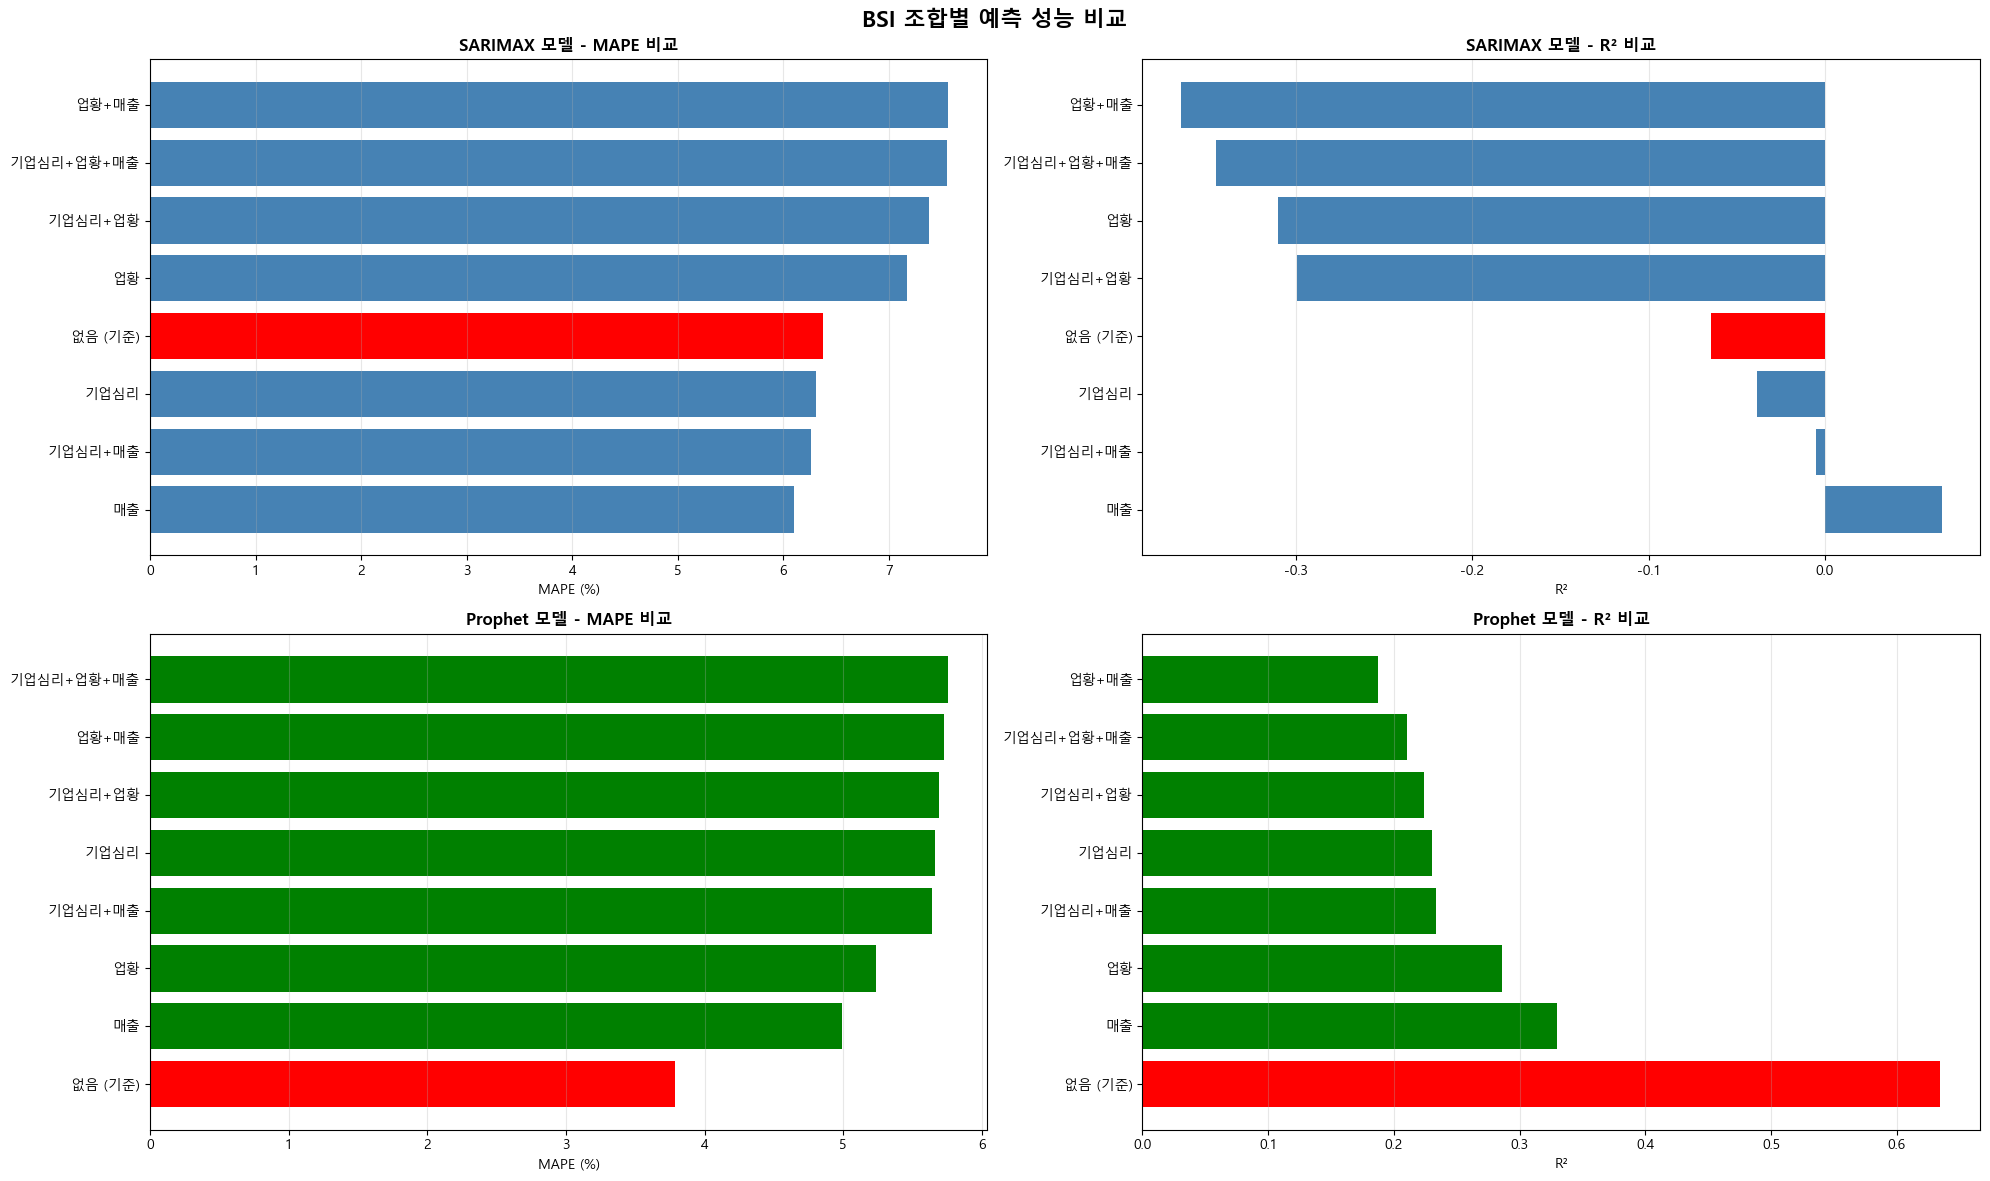

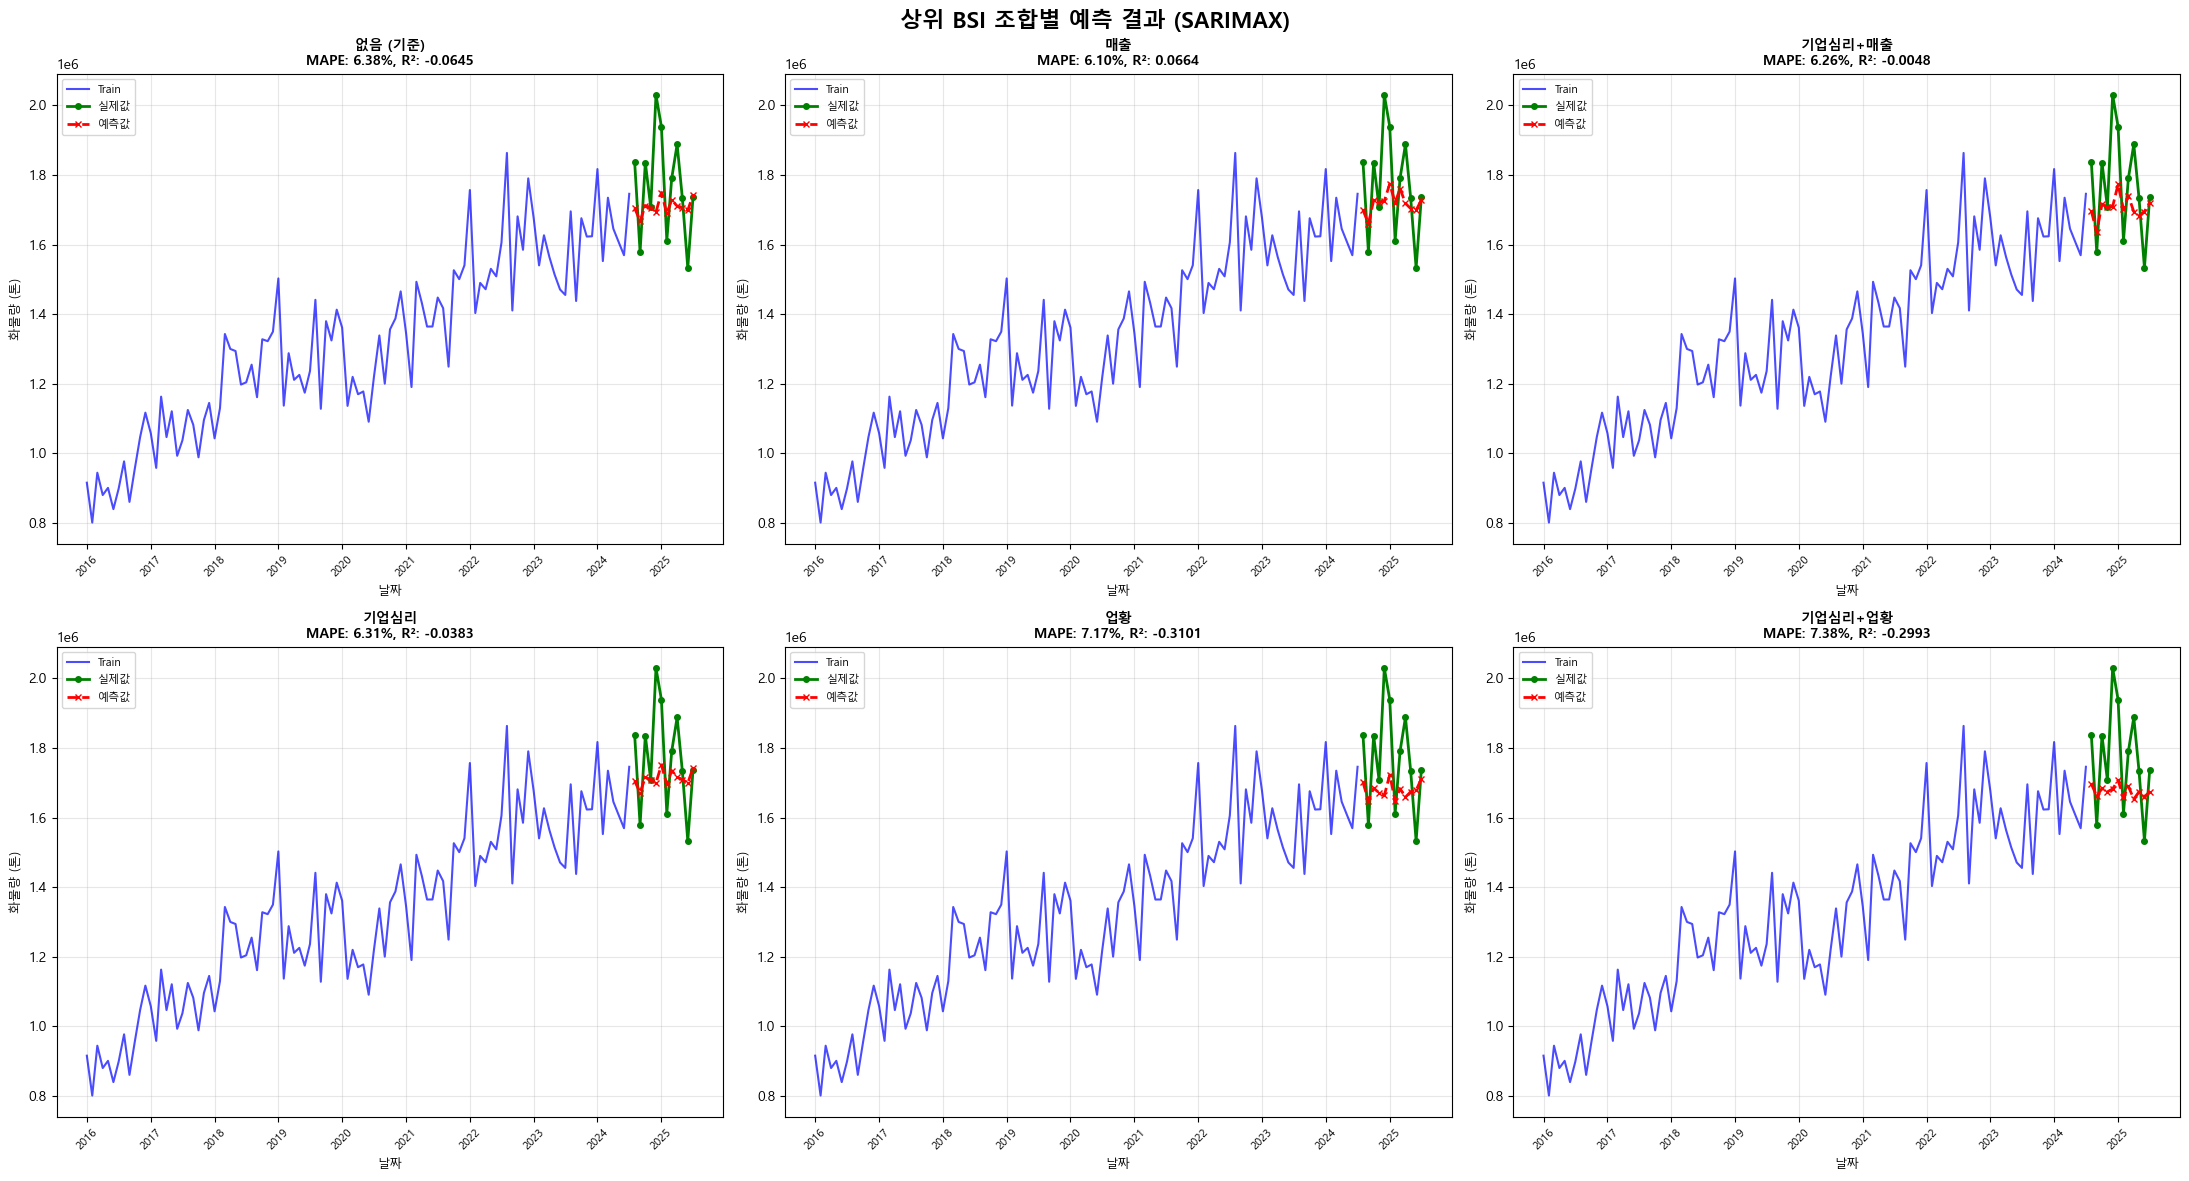

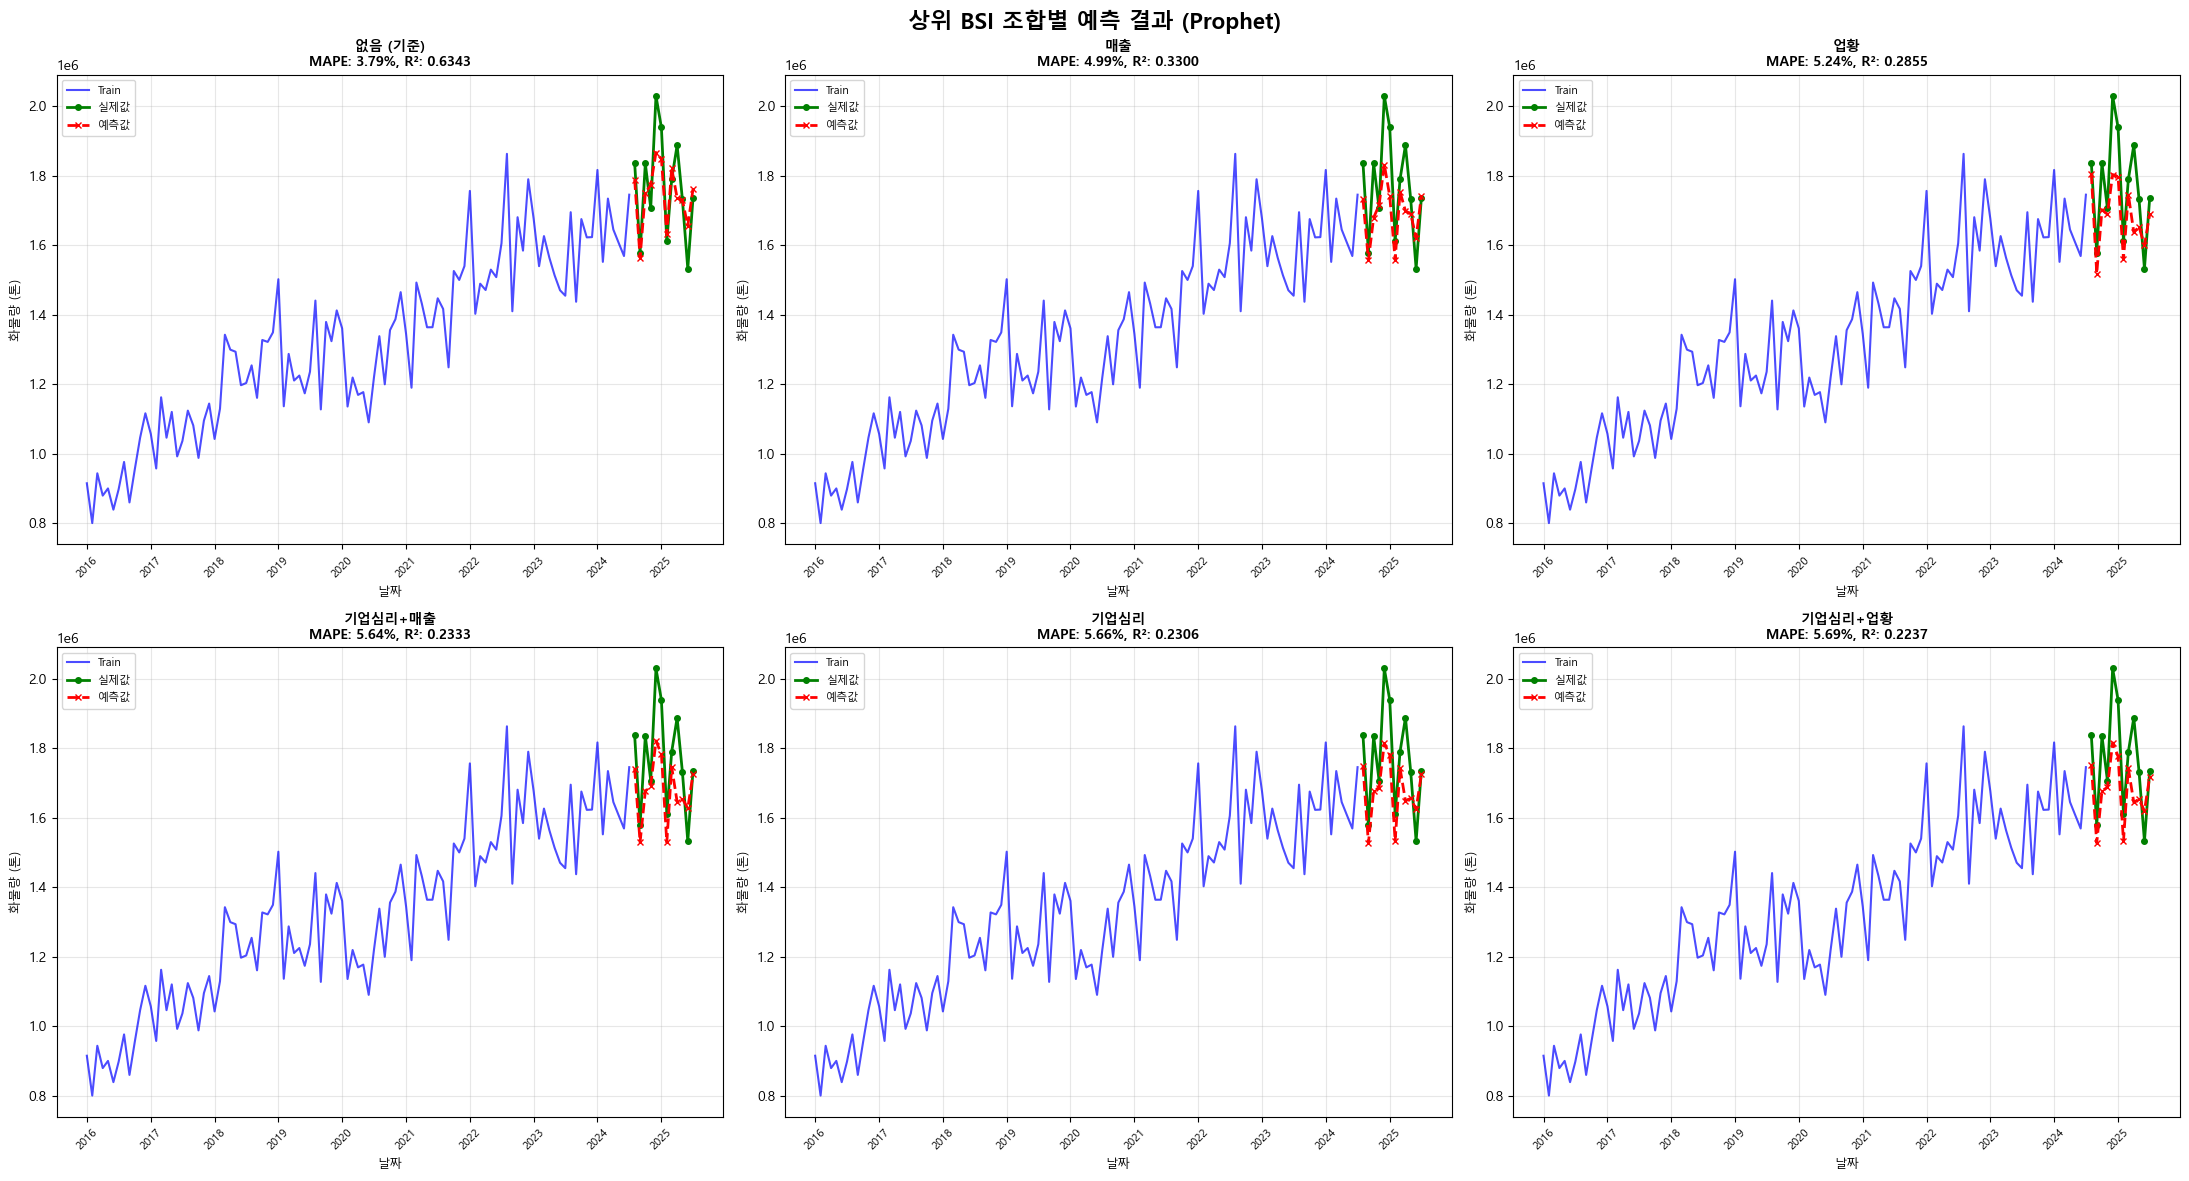

In [ ]:
"""
제주항 화물량 예측 모델 - BSI 조합별 분석
- SARIMA (외생변수 없음)
- SARIMAX (BSI 조합별)
- Prophet (외생변수 없음)
- Prophet (BSI 조합별)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

# 필요한 라이브러리
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import itertools
from datetime import datetime

print("=" * 80)
print("제주항 화물량 예측 시스템 - BSI 조합별 분석")
print("=" * 80)

# ========================================
# 1. 데이터 로드 및 전처리
# ========================================
print("\n[1단계] 데이터 로드 중...")

# 데이터 경로 (사용자 데스크탑)
DATA_PATH = r'C:\Users\DAEJIN\Desktop'

# 데이터 읽기
bsi_df = pd.read_excel(f'{DATA_PATH}/bsi data.xlsx')
port_df = pd.read_excel(f'{DATA_PATH}/port data.xlsx')

print(f"BSI 데이터: {bsi_df.shape}")
print(f"PORT 데이터: {port_df.shape}")

# year 컬럼 정수로 변환
bsi_df['year'] = bsi_df['year'].astype(int)
port_df['year'] = port_df['year'].astype(int)

# 날짜 컬럼 생성
bsi_df['date'] = pd.to_datetime(bsi_df['year'].astype(str) + '-' + bsi_df['month'].astype(str) + '-01')
port_df['date'] = pd.to_datetime(port_df['year'].astype(str) + '-' + port_df['month'].astype(str) + '-01')

# 데이터 병합 (port 데이터 기준)
df = port_df.merge(bsi_df[['date', '제조업 기업심리지수실적', '제조업 업황BSI', '제조업 매출BSI']],
                   on='date', how='left')

print(f"\n병합된 데이터: {df.shape}")
print(f"기간: {df['date'].min()} ~ {df['date'].max()}")

# ========================================
# 2. BSI 조합 생성
# ========================================
print("\n[2단계] BSI 조합 생성 중...")

# BSI 컬럼명
bsi_cols = ['제조업 기업심리지수실적', '제조업 업황BSI', '제조업 매출BSI']
bsi_short_names = ['기업심리', '업황', '매출']

# 모든 조합 생성
combinations = []

# 1개 조합
for i in range(len(bsi_cols)):
    combinations.append({
        'name': bsi_short_names[i],
        'cols': [bsi_cols[i]],
        'short': bsi_short_names[i]
    })

# 2개 조합
for i in range(len(bsi_cols)):
    for j in range(i+1, len(bsi_cols)):
        combinations.append({
            'name': f'{bsi_short_names[i]}+{bsi_short_names[j]}',
            'cols': [bsi_cols[i], bsi_cols[j]],
            'short': f'{bsi_short_names[i]}+{bsi_short_names[j]}'
        })

# 3개 조합
combinations.append({
    'name': '기업심리+업황+매출',
    'cols': bsi_cols,
    'short': '전체'
})

print(f"총 {len(combinations)}가지 BSI 조합:")
for idx, combo in enumerate(combinations, 1):
    print(f"  {idx}. {combo['name']}")

# ========================================
# 3. Train/Test 분할
# ========================================
print("\n[3단계] 데이터 분할 중...")

TEST_MONTHS = 12
FORECAST_MONTHS = 12

train_df = df.iloc[:-TEST_MONTHS].copy()
test_df = df.iloc[-TEST_MONTHS:].copy()

print(f"Train 데이터: {len(train_df)}개월 ({train_df['date'].min()} ~ {train_df['date'].max()})")
print(f"Test 데이터: {len(test_df)}개월 ({test_df['date'].min()} ~ {test_df['date'].max()})")

actual = test_df['화물량'].values

# ========================================
# 4. 평가 함수
# ========================================
def evaluate_model(predictions, actual):
    mae = mean_absolute_error(actual, predictions)
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    r2 = r2_score(actual, predictions)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

# ========================================
# 5. 기준 모델 (외생변수 없음)
# ========================================
print("\n[4단계] 기준 모델 학습 중...")
print("  - SARIMA (외생변수 없음)")
print("  - Prophet (외생변수 없음)")

# SARIMA 최적 파라미터 찾기
print("\n최적 SARIMA 파라미터 탐색 중...")
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

best_aic = np.inf
best_param = None
best_seasonal_param = None

for param in pdq:
    for seasonal_param in seasonal_pdq[:3]:
        try:
            model = SARIMAX(train_df['화물량'],
                          order=param,
                          seasonal_order=seasonal_param,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            results = model.fit(disp=False, maxiter=50)

            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_seasonal_param = seasonal_param
        except:
            continue

print(f"최적 파라미터: order={best_param}, seasonal_order={best_seasonal_param}")

# SARIMA 모델 학습
sarima_model = SARIMAX(train_df['화물량'],
                       order=best_param if best_param else (1, 1, 1),
                       seasonal_order=best_seasonal_param if best_seasonal_param else (1, 1, 1, 12))
sarima_results = sarima_model.fit(disp=False, maxiter=100)
sarima_forecast = sarima_results.forecast(steps=TEST_MONTHS)

# Prophet 모델 학습
prophet_train = train_df[['date', '화물량']].copy()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
prophet_forecast_df = prophet_model.predict(future)
prophet_forecast = prophet_forecast_df.iloc[-TEST_MONTHS:]['yhat'].values

# 기준 모델 평가
baseline_results = {
    'SARIMA': evaluate_model(sarima_forecast.values, actual),
    'Prophet': evaluate_model(prophet_forecast, actual)
}

print("\n기준 모델 성능:")
print(f"SARIMA  - MAPE: {baseline_results['SARIMA']['MAPE']:.2f}%, R²: {baseline_results['SARIMA']['R2']:.4f}")
print(f"Prophet - MAPE: {baseline_results['Prophet']['MAPE']:.2f}%, R²: {baseline_results['Prophet']['R2']:.4f}")

# ========================================
# 6. BSI 조합별 모델 학습
# ========================================
print("\n[5단계] BSI 조합별 모델 학습 중...")

all_results = []
forecast_data = {
    'date': test_df['date'],
    'actual': actual
}

for idx, combo in enumerate(combinations, 1):
    print(f"\n진행 중: {idx}/{len(combinations)} - {combo['name']}")

    exog_cols = combo['cols']
    combo_name = combo['short']

    # SARIMAX 모델
    try:
        sarimax_model = SARIMAX(
            train_df['화물량'],
            exog=train_df[exog_cols],
            order=best_param if best_param else (1, 1, 1),
            seasonal_order=best_seasonal_param if best_seasonal_param else (1, 1, 1, 12)
        )
        sarimax_results = sarimax_model.fit(disp=False, maxiter=100)
        sarimax_forecast = sarimax_results.forecast(steps=TEST_MONTHS, exog=test_df[exog_cols])
        sarimax_metrics = evaluate_model(sarimax_forecast.values, actual)

        # 예측값 저장
        forecast_data[f'SARIMAX_{combo_name}'] = sarimax_forecast.values

    except Exception as e:
        print(f"  SARIMAX 실패: {str(e)}")
        sarimax_metrics = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'R2': np.nan}
        forecast_data[f'SARIMAX_{combo_name}'] = [np.nan] * TEST_MONTHS

    # Prophet 모델 (외생변수 포함)
    try:
        prophet_train_exog = train_df[['date', '화물량'] + exog_cols].copy()
        prophet_train_exog.columns = ['ds', 'y'] + exog_cols

        prophet_exog_model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative'
        )

        for col in exog_cols:
            prophet_exog_model.add_regressor(col)

        prophet_exog_model.fit(prophet_train_exog)

        # 예측용 데이터프레임
        future_exog = prophet_model.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
        full_df = pd.concat([train_df, test_df], ignore_index=True)
        future_exog = future_exog.merge(full_df[['date'] + exog_cols],
                                       left_on='ds', right_on='date', how='left')

        for col in exog_cols:
            future_exog[col].fillna(method='ffill', inplace=True)

        prophet_exog_forecast_df = prophet_exog_model.predict(future_exog)
        prophet_exog_forecast = prophet_exog_forecast_df.iloc[-TEST_MONTHS:]['yhat'].values
        prophet_exog_metrics = evaluate_model(prophet_exog_forecast, actual)

        # 예측값 저장
        forecast_data[f'Prophet_{combo_name}'] = prophet_exog_forecast

    except Exception as e:
        print(f"  Prophet 실패: {str(e)}")
        prophet_exog_metrics = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'R2': np.nan}
        forecast_data[f'Prophet_{combo_name}'] = [np.nan] * TEST_MONTHS

    # 결과 저장
    all_results.append({
        'BSI_조합': combo['name'],
        'BSI_개수': len(exog_cols),
        'SARIMAX_MAE': sarimax_metrics['MAE'],
        'SARIMAX_RMSE': sarimax_metrics['RMSE'],
        'SARIMAX_MAPE': sarimax_metrics['MAPE'],
        'SARIMAX_R2': sarimax_metrics['R2'],
        'Prophet_MAE': prophet_exog_metrics['MAE'],
        'Prophet_RMSE': prophet_exog_metrics['RMSE'],
        'Prophet_MAPE': prophet_exog_metrics['MAPE'],
        'Prophet_R2': prophet_exog_metrics['R2']
    })

    print(f"  SARIMAX - MAPE: {sarimax_metrics['MAPE']:.2f}%, R²: {sarimax_metrics['R2']:.4f}")
    print(f"  Prophet - MAPE: {prophet_exog_metrics['MAPE']:.2f}%, R²: {prophet_exog_metrics['R2']:.4f}")

# ========================================
# 7. 결과 정리
# ========================================
print("\n[6단계] 결과 정리 중...")

# 기준 모델 추가
baseline_row = {
    'BSI_조합': '없음 (기준)',
    'BSI_개수': 0,
    'SARIMAX_MAE': baseline_results['SARIMA']['MAE'],
    'SARIMAX_RMSE': baseline_results['SARIMA']['RMSE'],
    'SARIMAX_MAPE': baseline_results['SARIMA']['MAPE'],
    'SARIMAX_R2': baseline_results['SARIMA']['R2'],
    'Prophet_MAE': baseline_results['Prophet']['MAE'],
    'Prophet_RMSE': baseline_results['Prophet']['RMSE'],
    'Prophet_MAPE': baseline_results['Prophet']['MAPE'],
    'Prophet_R2': baseline_results['Prophet']['R2']
}

all_results.insert(0, baseline_row)

# 데이터프레임 생성
results_df = pd.DataFrame(all_results)

# 기준 모델 대비 개선율 계산
baseline_sarimax_mape = baseline_results['SARIMA']['MAPE']
baseline_prophet_mape = baseline_results['Prophet']['MAPE']

results_df['SARIMAX_개선율(%)'] = ((baseline_sarimax_mape - results_df['SARIMAX_MAPE']) / baseline_sarimax_mape * 100).round(2)
results_df['Prophet_개선율(%)'] = ((baseline_prophet_mape - results_df['Prophet_MAPE']) / baseline_prophet_mape * 100).round(2)

# 정렬
results_df_sarimax = results_df.sort_values('SARIMAX_MAPE').reset_index(drop=True)
results_df_prophet = results_df.sort_values('Prophet_MAPE').reset_index(drop=True)

# ========================================
# 8. 결과 출력
# ========================================
print("\n" + "=" * 80)
print("BSI 조합별 성능 비교 결과")
print("=" * 80)

print("\n📊 SARIMAX 모델 순위 (MAPE 기준)")
print("-" * 80)
print(f"{'순위':<4} {'BSI 조합':<20} {'MAPE':<10} {'R²':<10} {'개선율':<10}")
print("-" * 80)
for idx, row in results_df_sarimax.head(10).iterrows():
    print(f"{idx+1:<4} {row['BSI_조합']:<20} {row['SARIMAX_MAPE']:>8.2f}% {row['SARIMAX_R2']:>9.4f} {row['SARIMAX_개선율(%)']:>8.2f}%")

print("\n📊 Prophet 모델 순위 (MAPE 기준)")
print("-" * 80)
print(f"{'순위':<4} {'BSI 조합':<20} {'MAPE':<10} {'R²':<10} {'개선율':<10}")
print("-" * 80)
for idx, row in results_df_prophet.head(10).iterrows():
    print(f"{idx+1:<4} {row['BSI_조합']:<20} {row['Prophet_MAPE']:>8.2f}% {row['Prophet_R2']:>9.4f} {row['Prophet_개선율(%)']:>8.2f}%")

# ========================================
# 9. 시각화
# ========================================
print("\n[7단계] 결과 시각화 중...")

# 1. 조합별 성능 비교 그래프
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('BSI 조합별 예측 성능 비교', fontsize=16, fontweight='bold')

# SARIMAX MAPE
ax1 = axes[0, 0]
data_sarimax = results_df.sort_values('SARIMAX_MAPE')
colors = ['red' if x == 0 else 'steelblue' for x in data_sarimax['BSI_개수']]
ax1.barh(data_sarimax['BSI_조합'], data_sarimax['SARIMAX_MAPE'], color=colors)
ax1.set_xlabel('MAPE (%)', fontsize=10)
ax1.set_title('SARIMAX 모델 - MAPE 비교', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# SARIMAX R²
ax2 = axes[0, 1]
data_sarimax_r2 = results_df.sort_values('SARIMAX_R2', ascending=False)
colors_r2 = ['red' if x == 0 else 'steelblue' for x in data_sarimax_r2['BSI_개수']]
ax2.barh(data_sarimax_r2['BSI_조합'], data_sarimax_r2['SARIMAX_R2'], color=colors_r2)
ax2.set_xlabel('R²', fontsize=10)
ax2.set_title('SARIMAX 모델 - R² 비교', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Prophet MAPE
ax3 = axes[1, 0]
data_prophet = results_df.sort_values('Prophet_MAPE')
colors_p = ['red' if x == 0 else 'green' for x in data_prophet['BSI_개수']]
ax3.barh(data_prophet['BSI_조합'], data_prophet['Prophet_MAPE'], color=colors_p)
ax3.set_xlabel('MAPE (%)', fontsize=10)
ax3.set_title('Prophet 모델 - MAPE 비교', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Prophet R²
ax4 = axes[1, 1]
data_prophet_r2 = results_df.sort_values('Prophet_R2', ascending=False)
colors_pr2 = ['red' if x == 0 else 'green' for x in data_prophet_r2['BSI_개수']]
ax4.barh(data_prophet_r2['BSI_조합'], data_prophet_r2['Prophet_R2'], color=colors_pr2)
ax4.set_xlabel('R²', fontsize=10)
ax4.set_title('Prophet 모델 - R² 비교', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/BSI조합별_성능비교.png', dpi=300, bbox_inches='tight')
print(f"그래프 저장 완료: {DATA_PATH}/BSI조합별_성능비교.png")

# 2. 상위 5개 조합 예측 결과 비교
fig2, axes2 = plt.subplots(2, 3, figsize=(22, 12))
fig2.suptitle('상위 BSI 조합별 예측 결과 (SARIMAX)', fontsize=16, fontweight='bold')

# 기준 모델 + 상위 5개 조합
top_combinations = ['없음 (기준)'] + results_df_sarimax[results_df_sarimax['BSI_조합'] != '없음 (기준)'].head(5)['BSI_조합'].tolist()

for idx, combo_name in enumerate(top_combinations):
    if idx >= 6:
        break

    ax = axes2[idx // 3, idx % 3]

    # Train 데이터
    ax.plot(train_df['date'], train_df['화물량'], label='Train', color='blue', linewidth=1.5, alpha=0.7)

    # Test 실제값
    ax.plot(test_df['date'], actual, label='실제값', color='green', linewidth=2, marker='o', markersize=4)

    # 예측값
    if combo_name == '없음 (기준)':
        pred = sarima_forecast.values
        mape = baseline_results['SARIMA']['MAPE']
        r2 = baseline_results['SARIMA']['R2']
    else:
        # 컬럼명 찾기
        short_name = results_df[results_df['BSI_조합'] == combo_name]['BSI_조합'].values[0]
        for combo in combinations:
            if combo['name'] == combo_name:
                col_name = f"SARIMAX_{combo['short']}"
                break
        pred = forecast_data.get(col_name, [np.nan] * TEST_MONTHS)
        mape = results_df[results_df['BSI_조합'] == combo_name]['SARIMAX_MAPE'].values[0]
        r2 = results_df[results_df['BSI_조합'] == combo_name]['SARIMAX_R2'].values[0]

    ax.plot(test_df['date'], pred, label='예측값', color='red', linewidth=2, linestyle='--', marker='x', markersize=4)

    ax.set_title(f'{combo_name}\nMAPE: {mape:.2f}%, R²: {r2:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('날짜', fontsize=9)
    ax.set_ylabel('화물량 (톤)', fontsize=9)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/상위조합_예측결과_SARIMAX.png', dpi=300, bbox_inches='tight')
print(f"그래프 저장 완료: {DATA_PATH}/상위조합_예측결과_SARIMAX.png")

# 3. Prophet 상위 조합
fig3, axes3 = plt.subplots(2, 3, figsize=(22, 12))
fig3.suptitle('상위 BSI 조합별 예측 결과 (Prophet)', fontsize=16, fontweight='bold')

top_combinations_prophet = ['없음 (기준)'] + results_df_prophet[results_df_prophet['BSI_조합'] != '없음 (기준)'].head(5)['BSI_조합'].tolist()

for idx, combo_name in enumerate(top_combinations_prophet):
    if idx >= 6:
        break

    ax = axes3[idx // 3, idx % 3]

    # Train 데이터
    ax.plot(train_df['date'], train_df['화물량'], label='Train', color='blue', linewidth=1.5, alpha=0.7)

    # Test 실제값
    ax.plot(test_df['date'], actual, label='실제값', color='green', linewidth=2, marker='o', markersize=4)

    # 예측값
    if combo_name == '없음 (기준)':
        pred = prophet_forecast
        mape = baseline_results['Prophet']['MAPE']
        r2 = baseline_results['Prophet']['R2']
    else:
        for combo in combinations:
            if combo['name'] == combo_name:
                col_name = f"Prophet_{combo['short']}"
                break
        pred = forecast_data.get(col_name, [np.nan] * TEST_MONTHS)
        mape = results_df[results_df['BSI_조합'] == combo_name]['Prophet_MAPE'].values[0]
        r2 = results_df[results_df['BSI_조합'] == combo_name]['Prophet_R2'].values[0]

    ax.plot(test_df['date'], pred, label='예측값', color='red', linewidth=2, linestyle='--', marker='x', markersize=4)

    ax.set_title(f'{combo_name}\nMAPE: {mape:.2f}%, R²: {r2:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('날짜', fontsize=9)
    ax.set_ylabel('화물량 (톤)', fontsize=9)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/상위조합_예측결과_Prophet.png', dpi=300, bbox_inches='tight')
print(f"그래프 저장 완료: {DATA_PATH}/상위조합_예측결과_Prophet.png")

# ========================================
# 10. 결과 저장
# ========================================
print("\n[8단계] 결과 저장 중...")

# 1. 전체 결과
results_df.to_excel(f'{DATA_PATH}/BSI조합별_전체결과.xlsx', index=False)
print(f"전체 결과 저장: {DATA_PATH}/BSI조합별_전체결과.xlsx")

# 2. 예측값 상세
forecast_df = pd.DataFrame(forecast_data)
forecast_df.to_excel(f'{DATA_PATH}/BSI조합별_예측값.xlsx', index=False)
print(f"예측값 저장: {DATA_PATH}/BSI조합별_예측값.xlsx")

# 3. 요약 리포트
with pd.ExcelWriter(f'{DATA_PATH}/BSI조합_분석리포트.xlsx', engine='openpyxl') as writer:
    # 시트 1: 전체 결과
    results_df.to_excel(writer, sheet_name='전체결과', index=False)

    # 시트 2: SARIMAX 순위
    results_df_sarimax.to_excel(writer, sheet_name='SARIMAX_순위', index=False)

    # 시트 3: Prophet 순위
    results_df_prophet.to_excel(writer, sheet_name='Prophet_순위', index=False)

    # 시트 4: 예측값
    forecast_df.to_excel(writer, sheet_name='예측값', index=False)

print(f"분석 리포트 저장: {DATA_PATH}/BSI조합_분석리포트.xlsx")

# ========================================
# 11. 최종 요약
# ========================================
print("\n" + "=" * 80)
print("분석 완료!")
print("=" * 80)

print(f"\n📁 생성된 파일:")
print(f"1. {DATA_PATH}/BSI조합별_성능비교.png")
print(f"2. {DATA_PATH}/상위조합_예측결과_SARIMAX.png")
print(f"3. {DATA_PATH}/상위조합_예측결과_Prophet.png")
print(f"4. {DATA_PATH}/BSI조합별_전체결과.xlsx")
print(f"5. {DATA_PATH}/BSI조합별_예측값.xlsx")
print(f"6. {DATA_PATH}/BSI조합_분석리포트.xlsx")

print("\n🏆 최고 성능 조합:")
print("-" * 80)
best_sarimax = results_df_sarimax.iloc[0]
best_prophet = results_df_prophet.iloc[0]

print(f"\nSARIMAX:")
print(f"  조합: {best_sarimax['BSI_조합']}")
print(f"  MAPE: {best_sarimax['SARIMAX_MAPE']:.2f}%")
print(f"  R²: {best_sarimax['SARIMAX_R2']:.4f}")
print(f"  개선율: {best_sarimax['SARIMAX_개선율(%)']:.2f}%")

print(f"\nProphet:")
print(f"  조합: {best_prophet['BSI_조합']}")
print(f"  MAPE: {best_prophet['Prophet_MAPE']:.2f}%")
print(f"  R²: {best_prophet['Prophet_R2']:.4f}")
print(f"  개선율: {best_prophet['Prophet_개선율(%)']:.2f}%")

print("\n" + "=" * 80)
print("💡 결론:")
print("-" * 80)

# BSI 포함 여부 효과 분석
bsi_models = results_df[results_df['BSI_조합'] != '없음 (기준)']
avg_sarimax_improvement = bsi_models['SARIMAX_개선율(%)'].mean()
avg_prophet_improvement = bsi_models['Prophet_개선율(%)'].mean()

if avg_sarimax_improvement > 0:
    print(f"✓ SARIMAX: BSI 변수 사용 시 평균 {avg_sarimax_improvement:.2f}% 성능 개선")
else:
    print(f"✗ SARIMAX: BSI 변수 사용 시 평균 {abs(avg_sarimax_improvement):.2f}% 성능 저하")

if avg_prophet_improvement > 0:
    print(f"✓ Prophet: BSI 변수 사용 시 평균 {avg_prophet_improvement:.2f}% 성능 개선")
else:
    print(f"✗ Prophet: BSI 변수 사용 시 평균 {abs(avg_prophet_improvement):.2f}% 성능 저하")

# 최적 변수 개수 분석
best_count_sarimax = results_df_sarimax.iloc[0]['BSI_개수']
best_count_prophet = results_df_prophet.iloc[0]['BSI_개수']

print(f"\n✓ SARIMAX 최적 BSI 변수 개수: {int(best_count_sarimax)}개")
print(f"✓ Prophet 최적 BSI 변수 개수: {int(best_count_prophet)}개")

print("\n" + "=" * 80)

# 업황만 비교

제주항 화물량 예측 시스템 - 제조업 업황BSI

[1단계] 데이터 로드 중...
BSI 데이터: (116, 5)
PORT 데이터: (115, 3)

병합된 데이터: (115, 5)
기간: 2016-01-01 00:00:00 ~ 2025-07-01 00:00:00
사용 외생변수: 제조업 업황BSI

결측치 확인:
year         0
month        0
화물량          0
date         0
제조업 업황BSI    0
dtype: int64

[2단계] 데이터 분할 중...
Train 데이터: 103개월 (2016-01-01 00:00:00 ~ 2024-07-01 00:00:00)
Test 데이터: 12개월 (2024-08-01 00:00:00 ~ 2025-07-01 00:00:00)

[3단계] SARIMA 모델 학습 중...
최적 파라미터 탐색 중... (약 1분 소요)
최적 파라미터: order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)
✓ SARIMA 모델 완료!

[4단계] SARIMAX 모델 학습 중...
✓ SARIMAX 모델 완료!

[5단계] Prophet 모델 학습 중...


17:14:11 - cmdstanpy - INFO - Chain [1] start processing
17:14:11 - cmdstanpy - INFO - Chain [1] done processing
17:14:11 - cmdstanpy - INFO - Chain [1] start processing
17:14:11 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet 모델 완료!

[6단계] Prophet + 업황BSI 모델 학습 중...
✓ Prophet + 업황BSI 모델 완료!

모델 성능 평가 (테스트 데이터)

1. SARIMA (외생변수 없음)
--------------------------------------------------
MAE:  83,465 톤
RMSE: 100,485 톤
MAPE: 4.83%
R²:   0.5028

2. SARIMAX (업황BSI 포함)
--------------------------------------------------
MAE:  72,295 톤
RMSE: 96,968 톤
MAPE: 4.06%
R²:   0.5370

3. Prophet (외생변수 없음)
--------------------------------------------------
MAE:  68,506 톤
RMSE: 86,172 톤
MAPE: 3.79%
R²:   0.6343

4. Prophet (업황BSI 포함)
--------------------------------------------------
MAE:  95,829 톤
RMSE: 120,453 톤
MAPE: 5.24%
R²:   0.2855

[7단계] 결과 시각화 중...
✓ 그래프 저장: C:\Users\DAEJIN\Desktop/제주항_화물량_예측결과_업황BSI.png
✓ 그래프 저장: C:\Users\DAEJIN\Desktop/모델_성능_비교_업황BSI.png

[8단계] 결과 저장 중...
✓ 테스트 결과 저장: C:\Users\DAEJIN\Desktop/테스트_예측결과_업황BSI.xlsx
✓ 미래 예측 저장: C:\Users\DAEJIN\Desktop/미래_12개월_예측_업황BSI.xlsx
✓ 평가 지표 저장: C:\Users\DAEJIN\Desktop/모델_평가지표_업황BSI.xlsx
✓ 종합 리포트 저장: C:\Users\DAEJIN\Desktop/제주항_예측_종합리포트_업황BSI.xlsx

분석 완료!

📁 

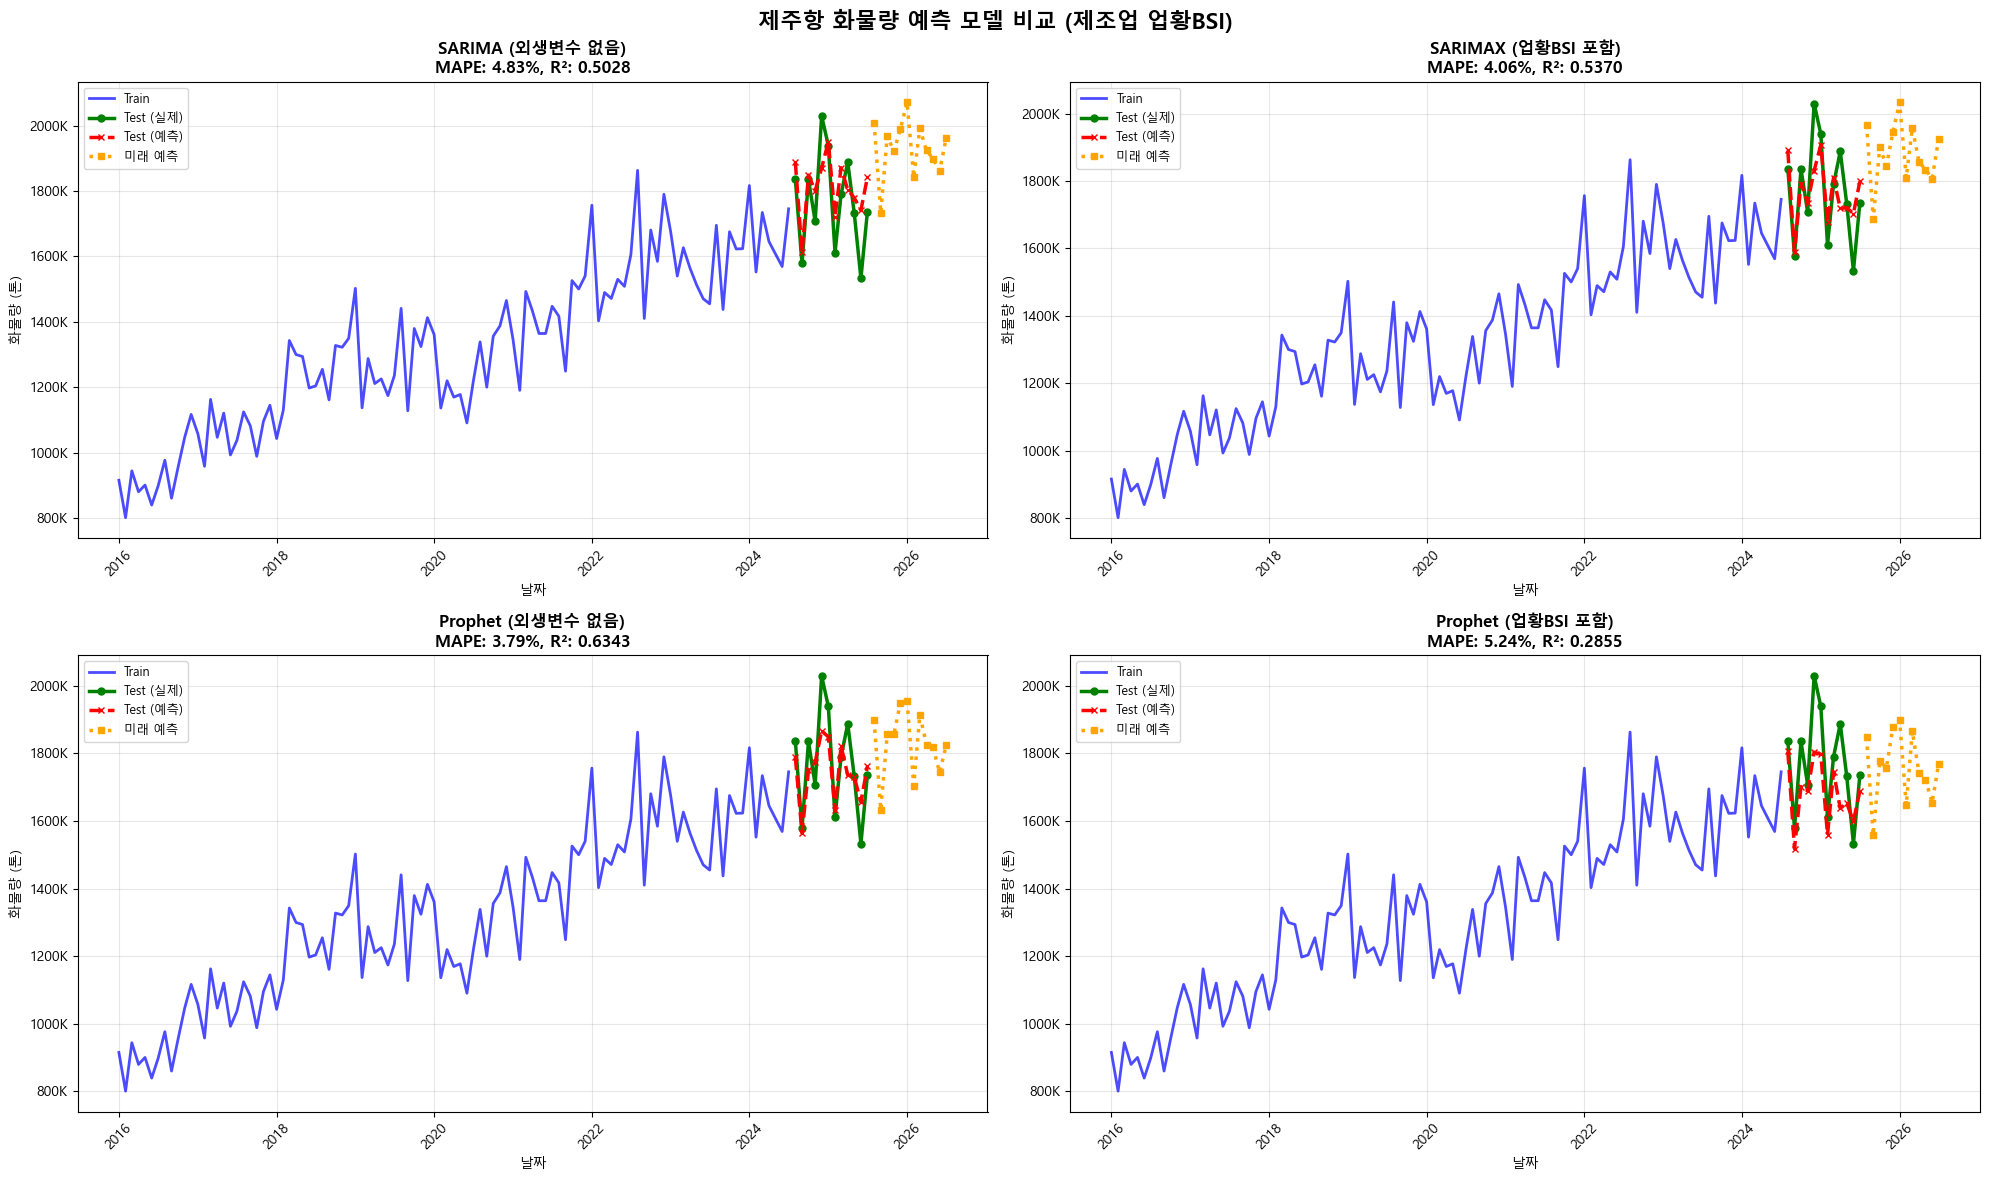

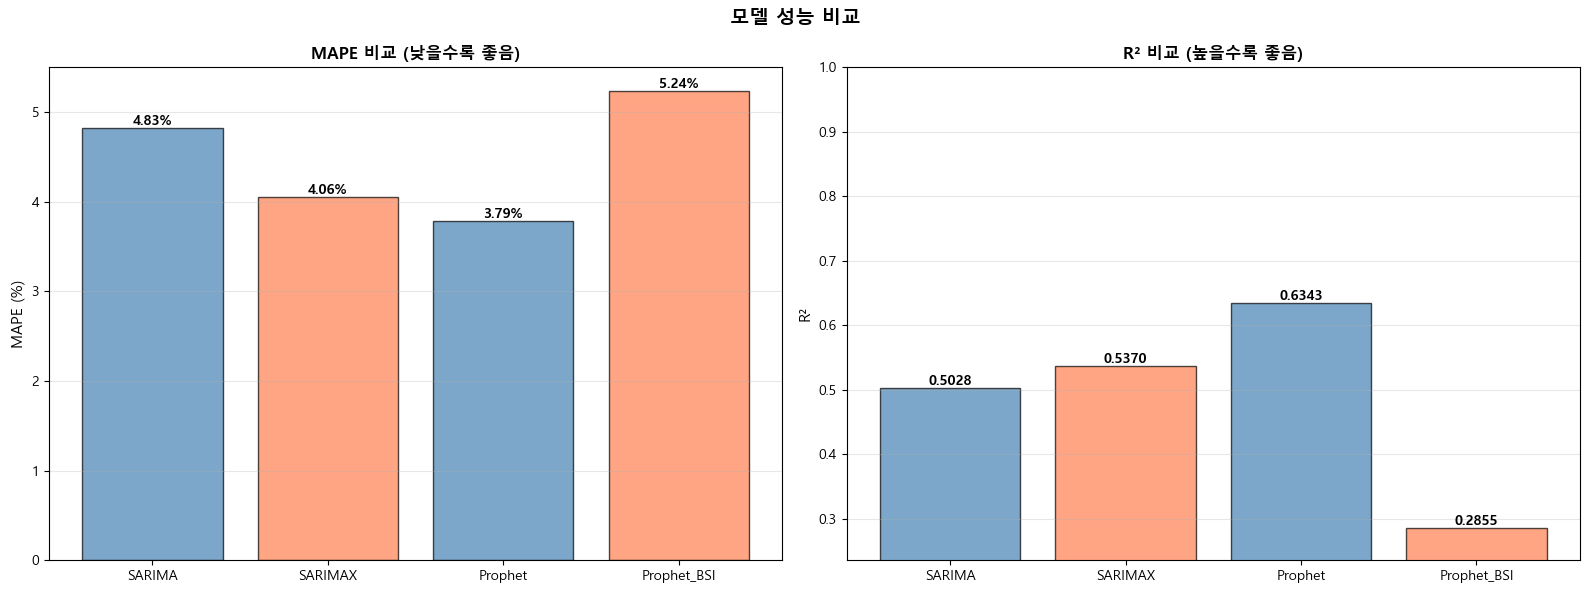

In [ ]:
"""
제주항 화물량 예측 모델 - 제조업 업황BSI 사용
- SARIMA (외생변수 없음)
- SARIMAX (업황BSI 포함)
- Prophet (외생변수 없음)
- Prophet (업황BSI 포함)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

# 필요한 라이브러리
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import itertools

print("=" * 80)
print("제주항 화물량 예측 시스템 - 제조업 업황BSI")
print("=" * 80)

# ========================================
# 1. 데이터 로드 및 전처리
# ========================================
print("\n[1단계] 데이터 로드 중...")

# 데이터 경로 (사용자 데스크탑)
DATA_PATH = r'C:\Users\DAEJIN\Desktop'

# 데이터 읽기
bsi_df = pd.read_excel(f'{DATA_PATH}/bsi data.xlsx')
port_df = pd.read_excel(f'{DATA_PATH}/port data.xlsx')

print(f"BSI 데이터: {bsi_df.shape}")
print(f"PORT 데이터: {port_df.shape}")

# year 컬럼 정수로 변환
bsi_df['year'] = bsi_df['year'].astype(int)
port_df['year'] = port_df['year'].astype(int)

# 날짜 컬럼 생성
bsi_df['date'] = pd.to_datetime(bsi_df['year'].astype(str) + '-' + bsi_df['month'].astype(str) + '-01')
port_df['date'] = pd.to_datetime(port_df['year'].astype(str) + '-' + port_df['month'].astype(str) + '-01')

# 데이터 병합 (제조업 업황BSI만 사용)
df = port_df.merge(bsi_df[['date', '제조업 업황BSI']], on='date', how='left')

print(f"\n병합된 데이터: {df.shape}")
print(f"기간: {df['date'].min()} ~ {df['date'].max()}")
print(f"사용 외생변수: 제조업 업황BSI")

# 결측치 확인
print(f"\n결측치 확인:")
print(df.isnull().sum())

# ========================================
# 2. Train/Test 분할
# ========================================
print("\n[2단계] 데이터 분할 중...")

TEST_MONTHS = 12
FORECAST_MONTHS = 12

train_df = df.iloc[:-TEST_MONTHS].copy()
test_df = df.iloc[-TEST_MONTHS:].copy()

print(f"Train 데이터: {len(train_df)}개월 ({train_df['date'].min()} ~ {train_df['date'].max()})")
print(f"Test 데이터: {len(test_df)}개월 ({test_df['date'].min()} ~ {test_df['date'].max()})")

actual = test_df['화물량'].values

# ========================================
# 3. 평가 함수
# ========================================
def evaluate_model(name, predictions, actual):
    mae = mean_absolute_error(actual, predictions)
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    r2 = r2_score(actual, predictions)

    print(f"\n{name}")
    print("-" * 50)
    print(f"MAE:  {mae:,.0f} 톤")
    print(f"RMSE: {rmse:,.0f} 톤")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²:   {r2:.4f}")

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# ========================================
# 4. 모델 1: SARIMA (외생변수 없음)
# ========================================
print("\n[3단계] SARIMA 모델 학습 중...")
print("최적 파라미터 탐색 중... (약 1분 소요)")

# 최적 파라미터 찾기
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

best_aic = np.inf
best_param = None
best_seasonal_param = None

for param in pdq:
    for seasonal_param in seasonal_pdq[:5]:  # 시간 절약
        try:
            model = SARIMAX(train_df['화물량'],
                          order=param,
                          seasonal_order=seasonal_param,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            results = model.fit(disp=False, maxiter=50)

            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_seasonal_param = seasonal_param
        except:
            continue

if best_param is None:
    best_param = (1, 1, 1)
    best_seasonal_param = (1, 1, 1, 12)

print(f"최적 파라미터: order={best_param}, seasonal_order={best_seasonal_param}")

# SARIMA 모델 학습
sarima_model = SARIMAX(train_df['화물량'],
                       order=best_param,
                       seasonal_order=best_seasonal_param)
sarima_results = sarima_model.fit(disp=False, maxiter=100)

# 예측
sarima_forecast_test = sarima_results.forecast(steps=TEST_MONTHS)
sarima_forecast_future = sarima_results.forecast(steps=TEST_MONTHS + FORECAST_MONTHS)

print("✓ SARIMA 모델 완료!")

# ========================================
# 5. 모델 2: SARIMAX (업황BSI 포함)
# ========================================
print("\n[4단계] SARIMAX 모델 학습 중...")

# SARIMAX 모델 (업황BSI 외생변수 포함)
sarimax_model = SARIMAX(train_df['화물량'],
                        exog=train_df[['제조업 업황BSI']],
                        order=best_param,
                        seasonal_order=best_seasonal_param)
sarimax_results = sarimax_model.fit(disp=False, maxiter=100)

# 예측 (테스트 기간)
sarimax_forecast_test = sarimax_results.forecast(steps=TEST_MONTHS,
                                                  exog=test_df[['제조업 업황BSI']])

# 미래 예측을 위한 업황BSI 준비 (마지막 값으로 연장)
last_bsi = test_df['제조업 업황BSI'].iloc[-1]
future_bsi = pd.DataFrame({'제조업 업황BSI': [last_bsi] * FORECAST_MONTHS})
future_bsi_combined = pd.concat([test_df[['제조업 업황BSI']], future_bsi], ignore_index=True)

sarimax_forecast_future = sarimax_results.forecast(steps=TEST_MONTHS + FORECAST_MONTHS,
                                                    exog=future_bsi_combined)

print("✓ SARIMAX 모델 완료!")

# ========================================
# 6. 모델 3: Prophet (외생변수 없음)
# ========================================
print("\n[5단계] Prophet 모델 학습 중...")

# Prophet용 데이터 포맷
prophet_train = train_df[['date', '화물량']].copy()
prophet_train.columns = ['ds', 'y']

# Prophet 모델
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

# 예측
future = prophet_model.make_future_dataframe(periods=TEST_MONTHS + FORECAST_MONTHS, freq='MS')
prophet_forecast_full = prophet_model.predict(future)

# 테스트 기간 예측값
prophet_forecast_test = prophet_forecast_full.iloc[-TEST_MONTHS-FORECAST_MONTHS:-FORECAST_MONTHS]['yhat'].values

# 미래 예측값
prophet_forecast_future = prophet_forecast_full.iloc[-FORECAST_MONTHS:]['yhat'].values

print("✓ Prophet 모델 완료!")

# ========================================
# 7. 모델 4: Prophet (업황BSI 포함)
# ========================================
print("\n[6단계] Prophet + 업황BSI 모델 학습 중...")

# Prophet용 데이터 (업황BSI 추가)
prophet_train_bsi = train_df[['date', '화물량', '제조업 업황BSI']].copy()
prophet_train_bsi.columns = ['ds', 'y', '제조업 업황BSI']

# Prophet 모델 (업황BSI regressor 추가)
prophet_bsi_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)
prophet_bsi_model.add_regressor('제조업 업황BSI')
prophet_bsi_model.fit(prophet_train_bsi)

# 예측용 데이터프레임
future_bsi_df = prophet_model.make_future_dataframe(periods=TEST_MONTHS + FORECAST_MONTHS, freq='MS')

# 전체 데이터 준비 (train + test + 미래)
full_df = pd.concat([train_df, test_df], ignore_index=True)

# 미래 날짜 생성
future_dates = pd.date_range(start=test_df['date'].iloc[-1] + pd.DateOffset(months=1),
                             periods=FORECAST_MONTHS, freq='MS')
future_data = pd.DataFrame({
    'date': future_dates,
    '제조업 업황BSI': [last_bsi] * FORECAST_MONTHS
})

# 전체 데이터 결합
full_df_with_future = pd.concat([full_df[['date', '제조업 업황BSI']], future_data], ignore_index=True)

# Prophet 예측용 데이터와 병합
future_bsi_df = future_bsi_df.merge(full_df_with_future, left_on='ds', right_on='date', how='left')
future_bsi_df['제조업 업황BSI'].fillna(method='ffill', inplace=True)

# 예측
prophet_bsi_forecast_full = prophet_bsi_model.predict(future_bsi_df)

# 테스트 기간 예측값
prophet_bsi_forecast_test = prophet_bsi_forecast_full.iloc[-TEST_MONTHS-FORECAST_MONTHS:-FORECAST_MONTHS]['yhat'].values

# 미래 예측값
prophet_bsi_forecast_future = prophet_bsi_forecast_full.iloc[-FORECAST_MONTHS:]['yhat'].values

print("✓ Prophet + 업황BSI 모델 완료!")

# ========================================
# 8. 모델 평가
# ========================================
print("\n" + "=" * 80)
print("모델 성능 평가 (테스트 데이터)")
print("=" * 80)

results = {}
results['SARIMA'] = evaluate_model("1. SARIMA (외생변수 없음)", sarima_forecast_test.values, actual)
results['SARIMAX'] = evaluate_model("2. SARIMAX (업황BSI 포함)", sarimax_forecast_test.values, actual)
results['Prophet'] = evaluate_model("3. Prophet (외생변수 없음)", prophet_forecast_test, actual)
results['Prophet_BSI'] = evaluate_model("4. Prophet (업황BSI 포함)", prophet_bsi_forecast_test, actual)

# ========================================
# 9. 시각화
# ========================================
print("\n[7단계] 결과 시각화 중...")

# 1. 4개 모델 비교 그래프
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('제주항 화물량 예측 모델 비교 (제조업 업황BSI)', fontsize=16, fontweight='bold')

models_data = [
    ('SARIMA (외생변수 없음)', sarima_forecast_test.values, sarima_forecast_future.values[-FORECAST_MONTHS:], 'SARIMA'),
    ('SARIMAX (업황BSI 포함)', sarimax_forecast_test.values, sarimax_forecast_future.values[-FORECAST_MONTHS:], 'SARIMAX'),
    ('Prophet (외생변수 없음)', prophet_forecast_test, prophet_forecast_future, 'Prophet'),
    ('Prophet (업황BSI 포함)', prophet_bsi_forecast_test, prophet_bsi_forecast_future, 'Prophet_BSI')
]

for idx, (name, test_pred, future_pred, key) in enumerate(models_data):
    ax = axes[idx // 2, idx % 2]

    # Train 데이터
    ax.plot(train_df['date'], train_df['화물량'], label='Train', color='blue', linewidth=2, alpha=0.7)

    # Test 실제값
    ax.plot(test_df['date'], actual, label='Test (실제)', color='green', linewidth=2.5, marker='o', markersize=5)

    # Test 예측값
    ax.plot(test_df['date'], test_pred, label='Test (예측)', color='red', linewidth=2.5, linestyle='--', marker='x', markersize=5)

    # 미래 예측
    future_dates = pd.date_range(start=test_df['date'].iloc[-1] + pd.DateOffset(months=1),
                                 periods=FORECAST_MONTHS, freq='MS')
    ax.plot(future_dates, future_pred, label='미래 예측', color='orange', linewidth=2.5, linestyle=':', marker='s', markersize=5)

    # 제목 및 성능 지표
    mape = results[key]['MAPE']
    r2 = results[key]['R2']
    ax.set_title(f'{name}\nMAPE: {mape:.2f}%, R²: {r2:.4f}', fontsize=12, fontweight='bold')

    ax.set_xlabel('날짜', fontsize=10)
    ax.set_ylabel('화물량 (톤)', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

    # y축 포맷팅
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/제주항_화물량_예측결과_업황BSI.png', dpi=300, bbox_inches='tight')
print(f"✓ 그래프 저장: {DATA_PATH}/제주항_화물량_예측결과_업황BSI.png")

# 2. 성능 비교 바 차트
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('모델 성능 비교', fontsize=14, fontweight='bold')

model_names = list(results.keys())
mapes = [results[m]['MAPE'] for m in model_names]
r2s = [results[m]['R2'] for m in model_names]

# MAPE 비교
ax1 = axes2[0]
colors = ['steelblue', 'coral', 'steelblue', 'coral']
bars1 = ax1.bar(model_names, mapes, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('MAPE (%)', fontsize=11)
ax1.set_title('MAPE 비교 (낮을수록 좋음)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 값 표시
for bar, mape in zip(bars1, mapes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{mape:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# R² 비교
ax2 = axes2[1]
bars2 = ax2.bar(model_names, r2s, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('R²', fontsize=11)
ax2.set_title('R² 비교 (높을수록 좋음)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([min(r2s) - 0.05, 1.0])

# 값 표시
for bar, r2 in zip(bars2, r2s):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{r2:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/모델_성능_비교_업황BSI.png', dpi=300, bbox_inches='tight')
print(f"✓ 그래프 저장: {DATA_PATH}/모델_성능_비교_업황BSI.png")

# ========================================
# 10. 결과 저장
# ========================================
print("\n[8단계] 결과 저장 중...")

# 테스트 기간 예측 결과
test_results_df = pd.DataFrame({
    '날짜': test_df['date'],
    '실제_화물량': actual,
    'SARIMA_예측': sarima_forecast_test.values,
    'SARIMAX_예측': sarimax_forecast_test.values,
    'Prophet_예측': prophet_forecast_test,
    'Prophet_BSI_예측': prophet_bsi_forecast_test
})

# 오차 계산
for model in ['SARIMA', 'SARIMAX', 'Prophet', 'Prophet_BSI']:
    test_results_df[f'{model}_오차'] = test_results_df['실제_화물량'] - test_results_df[f'{model}_예측']
    test_results_df[f'{model}_오차율(%)'] = (test_results_df[f'{model}_오차'] / test_results_df['실제_화물량'] * 100).round(2)

test_results_df.to_excel(f'{DATA_PATH}/테스트_예측결과_업황BSI.xlsx', index=False)
print(f"✓ 테스트 결과 저장: {DATA_PATH}/테스트_예측결과_업황BSI.xlsx")

# 미래 예측 결과
future_dates_list = pd.date_range(start=test_df['date'].iloc[-1] + pd.DateOffset(months=1),
                                   periods=FORECAST_MONTHS, freq='MS')

future_results_df = pd.DataFrame({
    '날짜': future_dates_list,
    'SARIMA_예측': sarima_forecast_future.values[-FORECAST_MONTHS:],
    'SARIMAX_예측': sarimax_forecast_future.values[-FORECAST_MONTHS:],
    'Prophet_예측': prophet_forecast_future,
    'Prophet_BSI_예측': prophet_bsi_forecast_future
})

future_results_df.to_excel(f'{DATA_PATH}/미래_12개월_예측_업황BSI.xlsx', index=False)
print(f"✓ 미래 예측 저장: {DATA_PATH}/미래_12개월_예측_업황BSI.xlsx")

# 모델 평가 지표
metrics_df = pd.DataFrame(results).T
metrics_df.to_excel(f'{DATA_PATH}/모델_평가지표_업황BSI.xlsx')
print(f"✓ 평가 지표 저장: {DATA_PATH}/모델_평가지표_업황BSI.xlsx")

# 종합 리포트
with pd.ExcelWriter(f'{DATA_PATH}/제주항_예측_종합리포트_업황BSI.xlsx', engine='openpyxl') as writer:
    # 시트 1: 요약
    summary_data = {
        '항목': ['데이터 기간', 'Train 기간', 'Test 기간', '외생변수', '최적 모델 (MAPE)', '최적 모델 (R²)'],
        '내용': [
            f"{df['date'].min().strftime('%Y-%m')} ~ {df['date'].max().strftime('%Y-%m')}",
            f"{train_df['date'].min().strftime('%Y-%m')} ~ {train_df['date'].max().strftime('%Y-%m')} ({len(train_df)}개월)",
            f"{test_df['date'].min().strftime('%Y-%m')} ~ {test_df['date'].max().strftime('%Y-%m')} ({len(test_df)}개월)",
            '제조업 업황BSI',
            min(results.items(), key=lambda x: x[1]['MAPE'])[0],
            max(results.items(), key=lambda x: x[1]['R2'])[0]
        ]
    }
    pd.DataFrame(summary_data).to_excel(writer, sheet_name='요약', index=False)

    # 시트 2: 모델 평가
    metrics_df.to_excel(writer, sheet_name='모델_평가지표')

    # 시트 3: 테스트 예측
    test_results_df.to_excel(writer, sheet_name='테스트_예측결과', index=False)

    # 시트 4: 미래 예측
    future_results_df.to_excel(writer, sheet_name='미래_12개월_예측', index=False)

print(f"✓ 종합 리포트 저장: {DATA_PATH}/제주항_예측_종합리포트_업황BSI.xlsx")

# ========================================
# 11. 최종 요약
# ========================================
print("\n" + "=" * 80)
print("분석 완료!")
print("=" * 80)

print(f"\n📁 생성된 파일:")
print(f"1. {DATA_PATH}/제주항_화물량_예측결과_업황BSI.png")
print(f"2. {DATA_PATH}/모델_성능_비교_업황BSI.png")
print(f"3. {DATA_PATH}/테스트_예측결과_업황BSI.xlsx")
print(f"4. {DATA_PATH}/미래_12개월_예측_업황BSI.xlsx")
print(f"5. {DATA_PATH}/모델_평가지표_업황BSI.xlsx")
print(f"6. {DATA_PATH}/제주항_예측_종합리포트_업황BSI.xlsx")

print("\n🏆 모델 성능 순위 (MAPE 기준)")
print("-" * 80)
sorted_models = sorted(results.items(), key=lambda x: x[1]['MAPE'])
for rank, (model, metrics) in enumerate(sorted_models, 1):
    print(f"{rank}. {model:20s} | MAPE: {metrics['MAPE']:6.2f}% | R²: {metrics['R2']:.4f}")

print("\n🏆 모델 성능 순위 (R² 기준)")
print("-" * 80)
sorted_models_r2 = sorted(results.items(), key=lambda x: x[1]['R2'], reverse=True)
for rank, (model, metrics) in enumerate(sorted_models_r2, 1):
    print(f"{rank}. {model:20s} | R²: {metrics['R2']:.4f} | MAPE: {metrics['MAPE']:6.2f}%")

# 외생변수 효과 분석
print("\n💡 외생변수 효과 분석")
print("-" * 80)

sarima_mape = results['SARIMA']['MAPE']
sarimax_mape = results['SARIMAX']['MAPE']
sarimax_improvement = ((sarima_mape - sarimax_mape) / sarima_mape) * 100

prophet_mape = results['Prophet']['MAPE']
prophet_bsi_mape = results['Prophet_BSI']['MAPE']
prophet_improvement = ((prophet_mape - prophet_bsi_mape) / prophet_mape) * 100

print(f"SARIMAX (업황BSI 포함) vs SARIMA (외생변수 없음):")
if sarimax_improvement > 0:
    print(f"  → 성능 개선: {sarimax_improvement:.2f}% ✓")
else:
    print(f"  → 성능 저하: {abs(sarimax_improvement):.2f}% ✗")

print(f"\nProphet (업황BSI 포함) vs Prophet (외생변수 없음):")
if prophet_improvement > 0:
    print(f"  → 성능 개선: {prophet_improvement:.2f}% ✓")
else:
    print(f"  → 성능 저하: {abs(prophet_improvement):.2f}% ✗")

print("\n" + "=" * 80)
print("🎯 결론:")
print("-" * 80)

best_model = min(results.items(), key=lambda x: x[1]['MAPE'])
print(f"✓ 최고 성능 모델: {best_model[0]}")
print(f"✓ MAPE: {best_model[1]['MAPE']:.2f}%")
print(f"✓ R²: {best_model[1]['R2']:.4f}")

avg_improvement = (sarimax_improvement + prophet_improvement) / 2
if avg_improvement > 0:
    print(f"\n✓ 제조업 업황BSI 사용 시 평균 {avg_improvement:.2f}% 성능 개선")
    print("✓ 외생변수 사용 권장!")
else:
    print(f"\n✗ 제조업 업황BSI 사용 시 평균 {abs(avg_improvement):.2f}% 성능 저하")
    print("✗ 외생변수 없는 모델 사용 권장")

print("\n" + "=" * 80)

# Rolling Origin

제주항 화물량 예측 시스템 - Rolling Origin 교차검증

[1단계] 데이터 로드 중...
BSI 데이터: (116, 5)
PORT 데이터: (115, 3)

병합된 데이터: (115, 5)
기간: 2016-01-01 00:00:00 ~ 2025-07-01 00:00:00
사용 외생변수: 제조업 업황BSI

[2단계] Rolling Origin 설정...
총 데이터: 115개월
초기 학습 크기: 70개월
테스트 윈도우: 12개월
스텝 크기: 3개월
Rolling Origin 분할 횟수: 12회

실제 분할 횟수: 12회
  Split 1: Train(2016-01~2021-10) → Test(2021-11~2022-10)
  Split 2: Train(2016-01~2022-01) → Test(2022-02~2023-01)
  Split 3: Train(2016-01~2022-04) → Test(2022-05~2023-04)
  Split 4: Train(2016-01~2022-07) → Test(2022-08~2023-07)
  Split 5: Train(2016-01~2022-10) → Test(2022-11~2023-10)
  Split 6: Train(2016-01~2023-01) → Test(2023-02~2024-01)
  Split 7: Train(2016-01~2023-04) → Test(2023-05~2024-04)
  Split 8: Train(2016-01~2023-07) → Test(2023-08~2024-07)
  Split 9: Train(2016-01~2023-10) → Test(2023-11~2024-10)
  Split 10: Train(2016-01~2024-01) → Test(2024-02~2025-01)
  Split 11: Train(2016-01~2024-04) → Test(2024-05~2025-04)
  Split 12: Train(2016-01~2024-07) → Test(2024-08~2025-07)

[

Rolling Origin 진행:   0%|                                                                      | 0/12 [00:00<?, ?it/s]17:17:29 - cmdstanpy - INFO - Chain [1] start processing
17:17:29 - cmdstanpy - INFO - Chain [1] done processing
17:17:29 - cmdstanpy - INFO - Chain [1] start processing
17:17:30 - cmdstanpy - INFO - Chain [1] done processing
Rolling Origin 진행:   8%|█████▏                                                        | 1/12 [00:00<00:08,  1.26it/s]17:17:30 - cmdstanpy - INFO - Chain [1] start processing
17:17:30 - cmdstanpy - INFO - Chain [1] done processing
17:17:30 - cmdstanpy - INFO - Chain [1] start processing
17:17:30 - cmdstanpy - INFO - Chain [1] done processing
Rolling Origin 진행:  17%|██████████▎                                                   | 2/12 [00:01<00:08,  1.17it/s]17:17:31 - cmdstanpy - INFO - Chain [1] start processing
17:17:31 - cmdstanpy - INFO - Chain [1] done processing
17:17:31 - cmdstanpy - INFO - Chain [1] start processing
17:17:31 - cmdstanpy - INFO

✓ Rolling Origin 교차검증 완료!

[5단계] 결과 집계 중...

Rolling Origin 교차검증 결과

총 12회 검증 수행

📊 모델별 평균 성능 (평균 ± 표준편차)
--------------------------------------------------------------------------------
모델                   MAPE (%)             RMSE (톤)                  R²                  
--------------------------------------------------------------------------------
SARIMA               5.70 ± 1.95          114,479 ± 26,643          0.0300 ± 0.5306     
SARIMAX              5.56 ± 1.34          111,740 ± 18,445          0.1479 ± 0.2334     
Prophet              5.46 ± 1.87          110,845 ± 29,880          0.0990 ± 0.4697     
Prophet_BSI          4.89 ± 0.77          103,262 ± 20,918          0.2955 ± 0.1789     

[6단계] 최종 모델 학습 중...
최종 Train: 103개월
최종 Test: 12개월


17:17:38 - cmdstanpy - INFO - Chain [1] done processing
17:17:38 - cmdstanpy - INFO - Chain [1] start processing
17:17:38 - cmdstanpy - INFO - Chain [1] done processing



최종 모델 성능 (마지막 12개월 테스트):
--------------------------------------------------------------------------------
SARIMA               | MAPE:   4.83% | R²: 0.5028
SARIMAX              | MAPE:   4.06% | R²: 0.5370
Prophet              | MAPE:   3.79% | R²: 0.6343
Prophet_BSI          | MAPE:   5.24% | R²: 0.2855

[7단계] 결과 시각화 중...
✓ 그래프 저장: C:\Users\DAEJIN\Desktop/Rolling_Origin_성능추이.png
✓ 그래프 저장: C:\Users\DAEJIN\Desktop/Rolling_Origin_평균성능.png
✓ 그래프 저장: C:\Users\DAEJIN\Desktop/최종모델_예측결과.png

[8단계] 결과 저장 중...
✓ Rolling Origin 상세 결과 저장: C:\Users\DAEJIN\Desktop/Rolling_Origin_상세결과.xlsx
✓ 평균 성능 저장: C:\Users\DAEJIN\Desktop/Rolling_Origin_평균성능.xlsx
✓ 최종 예측 결과 저장: C:\Users\DAEJIN\Desktop/최종모델_예측결과.xlsx
✓ 종합 리포트 저장: C:\Users\DAEJIN\Desktop/Rolling_Origin_종합리포트.xlsx

분석 완료!

📁 생성된 파일:
1. C:\Users\DAEJIN\Desktop/Rolling_Origin_성능추이.png
2. C:\Users\DAEJIN\Desktop/Rolling_Origin_평균성능.png
3. C:\Users\DAEJIN\Desktop/최종모델_예측결과.png
4. C:\Users\DAEJIN\Desktop/Rolling_Origin_상세결과.xlsx
5. C:\Users\DAEJIN\Deskt

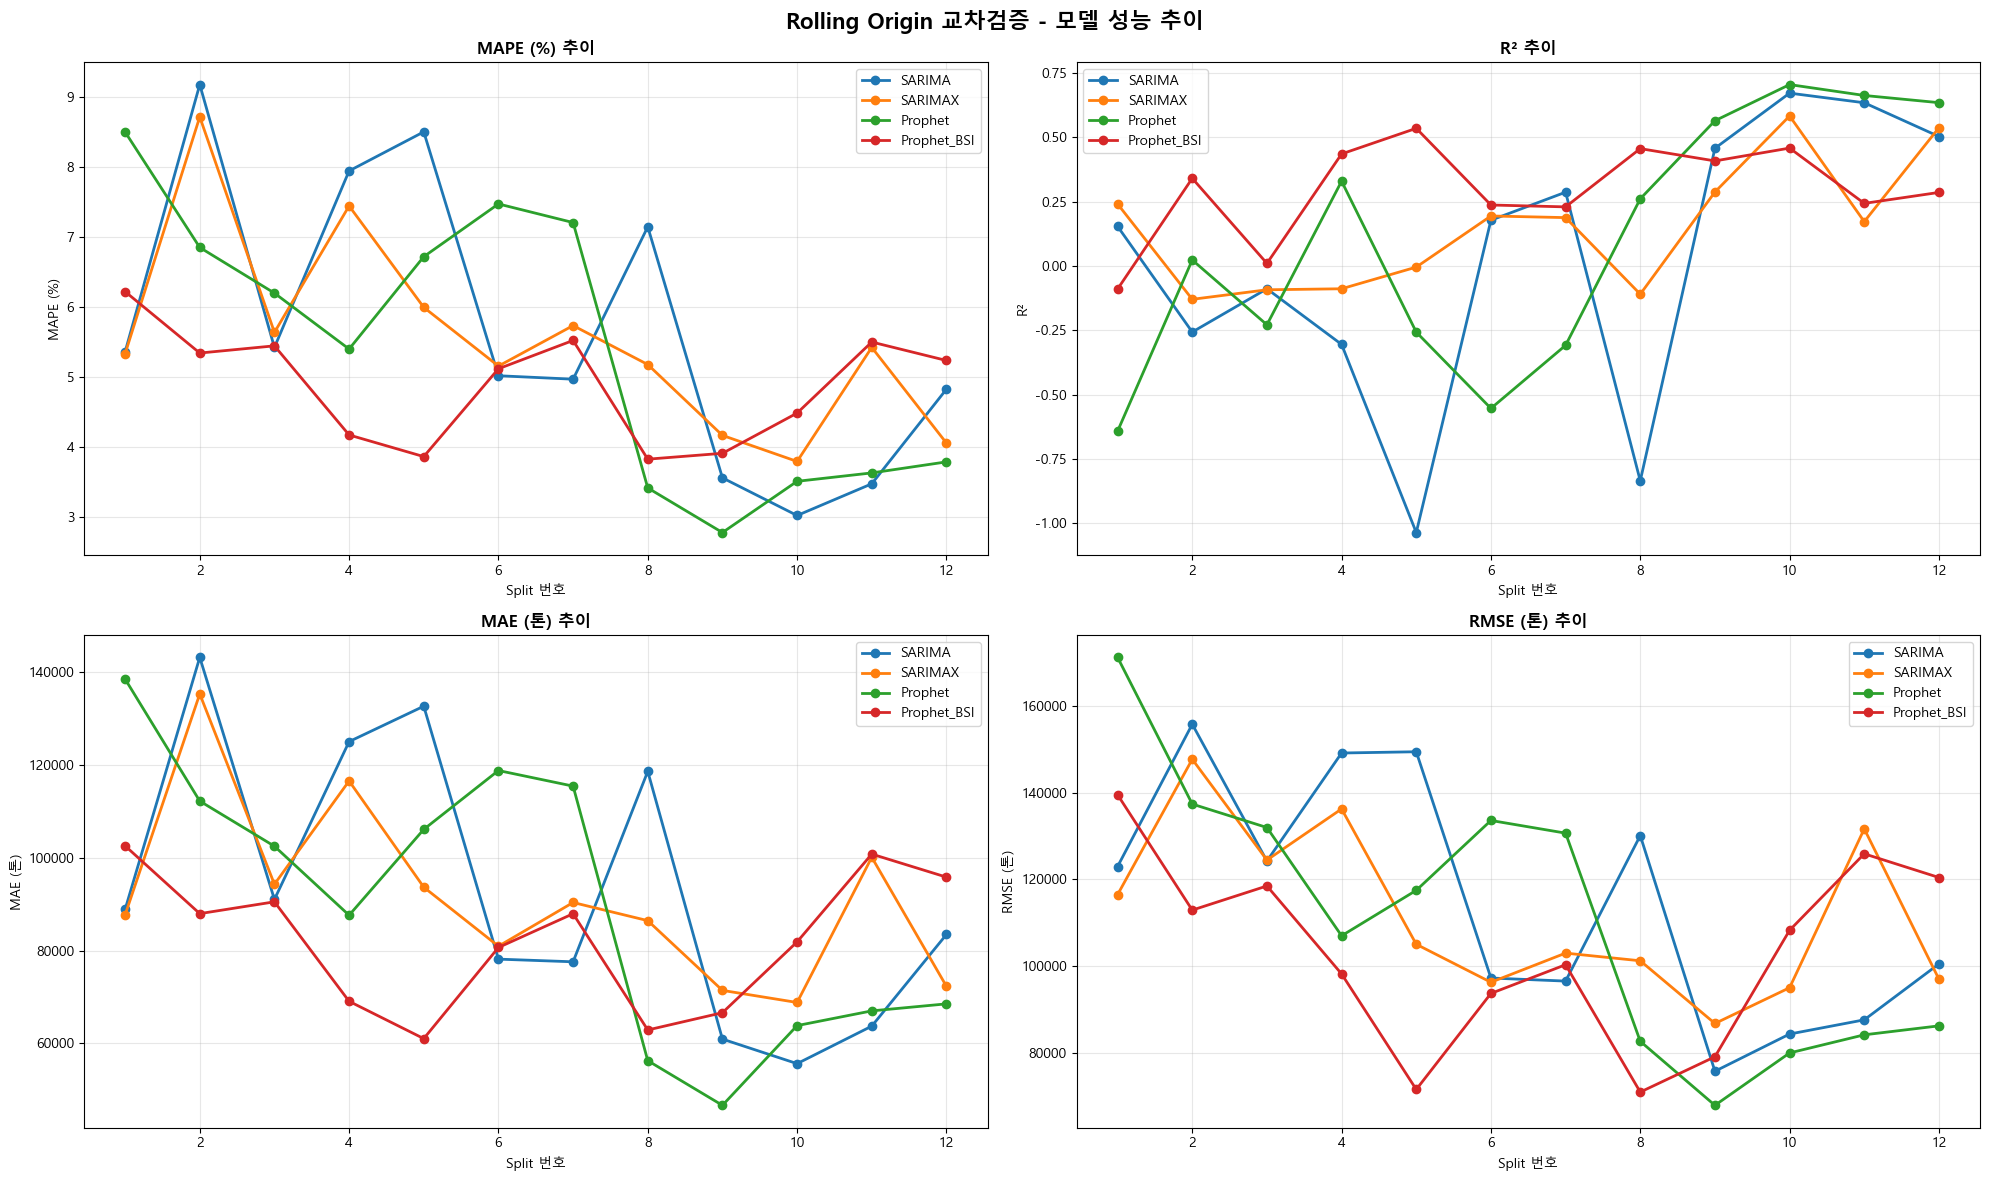

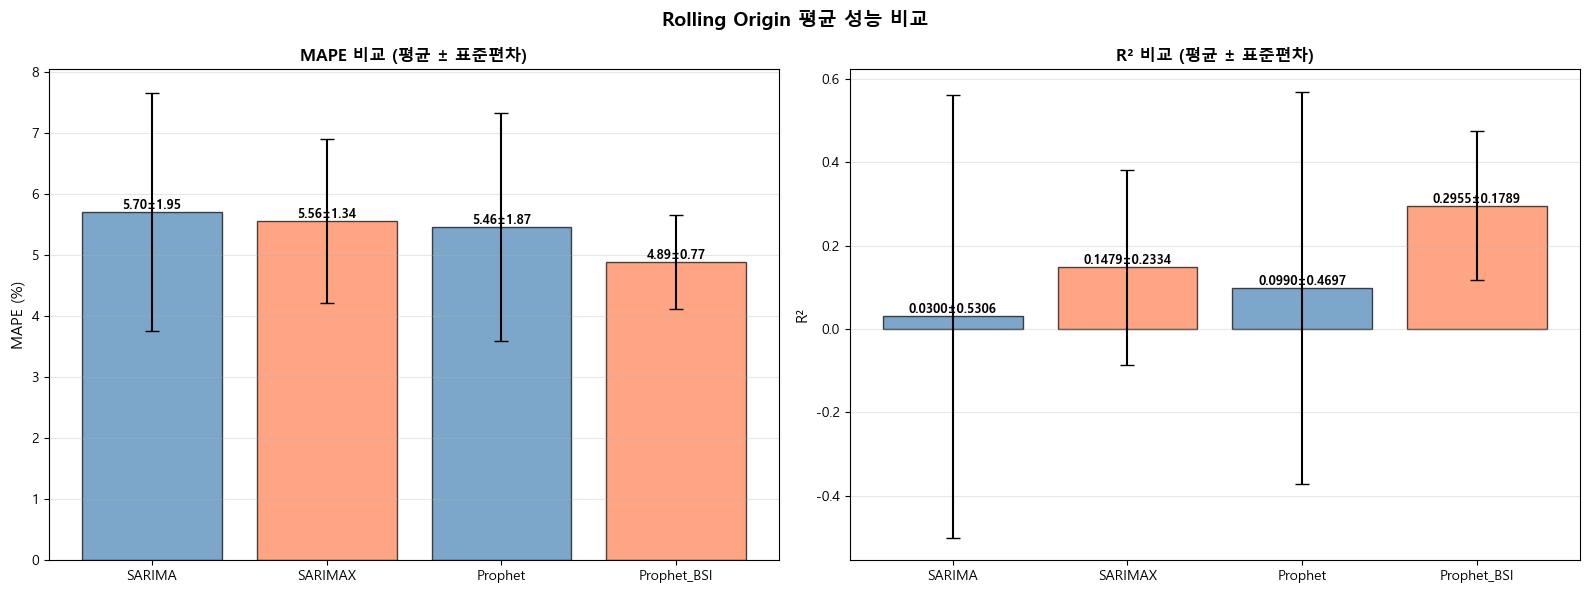

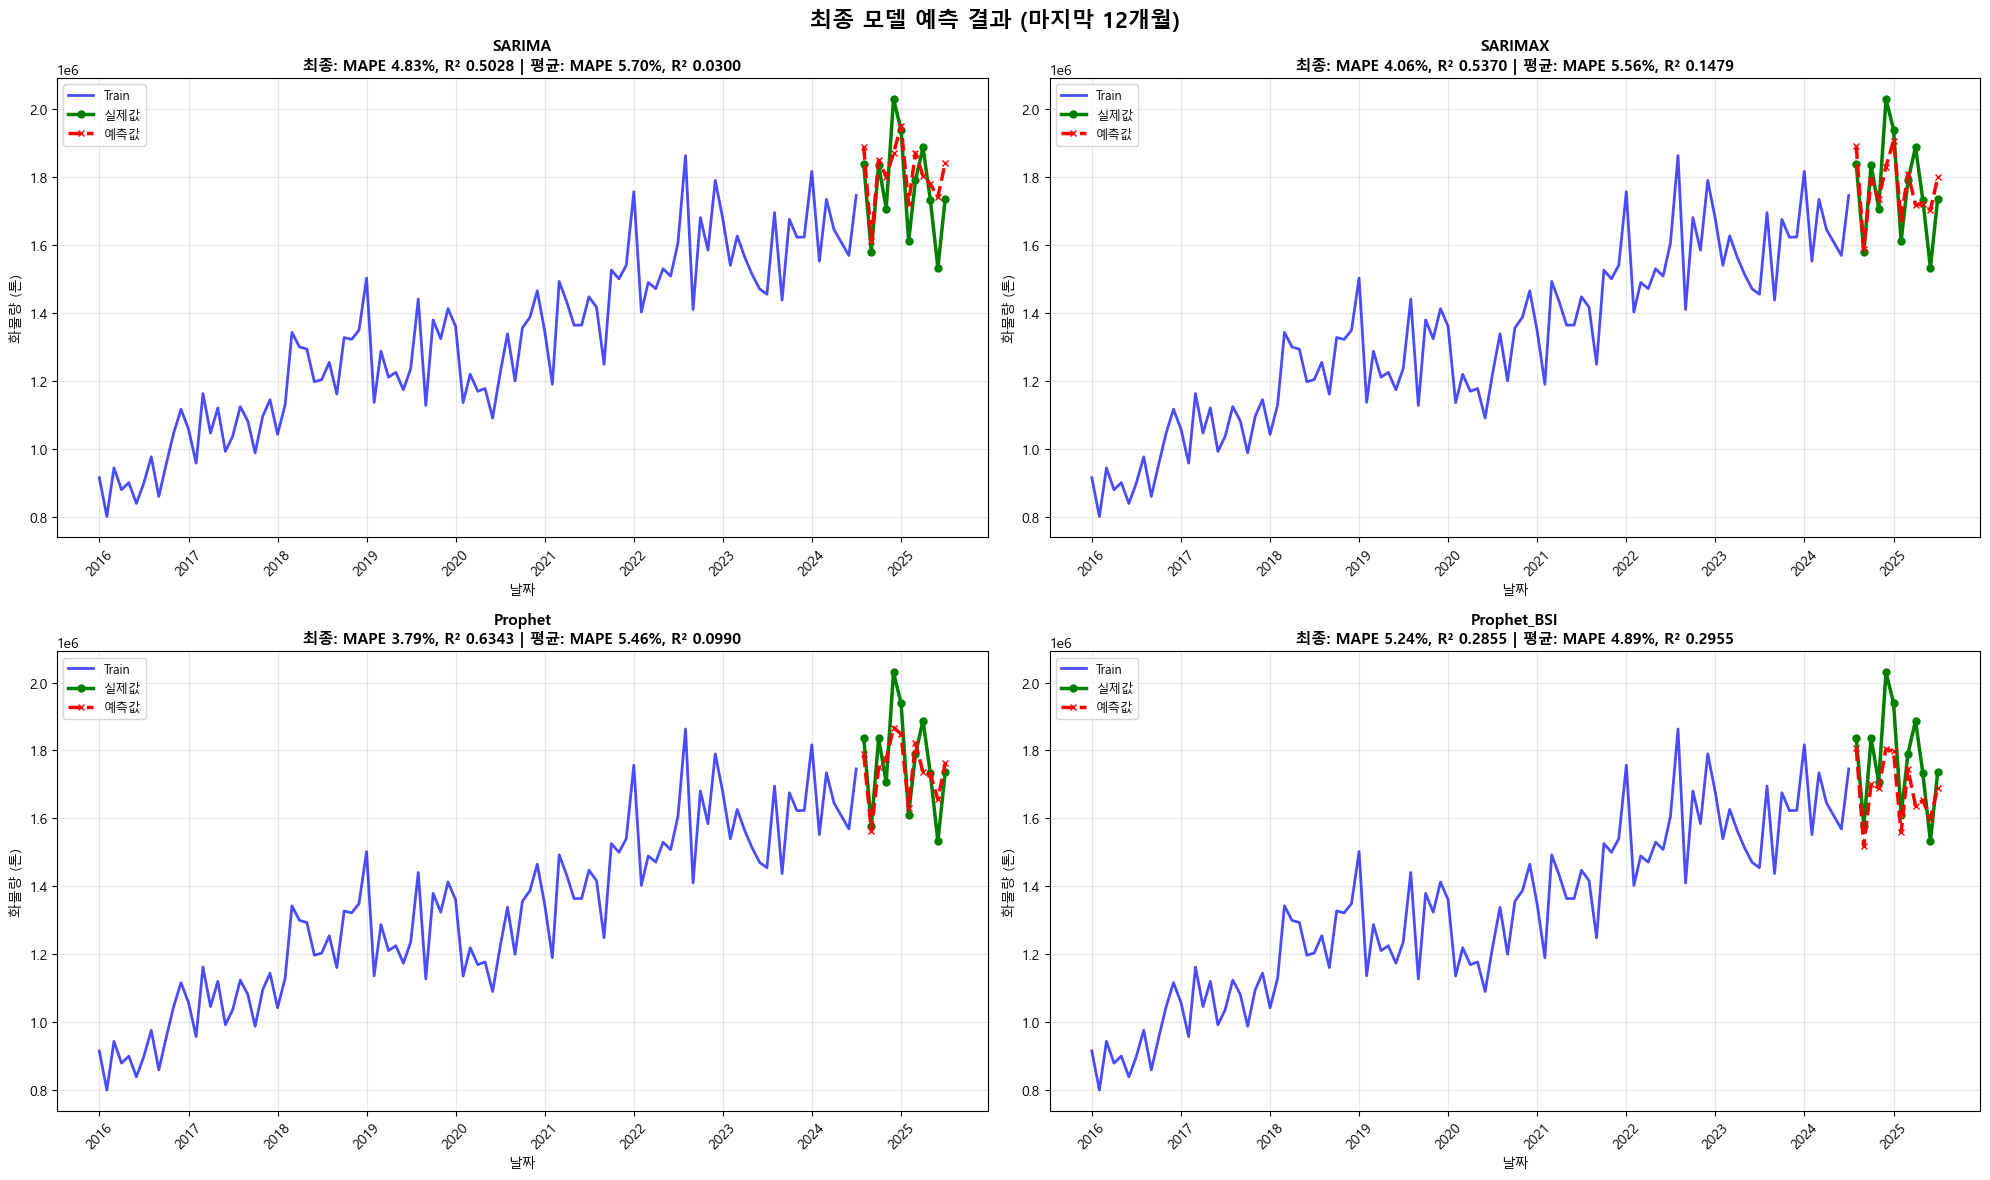

In [ ]:
"""
제주항 화물량 예측 모델 - 제조업 업황BSI + Rolling Origin 교차검증
- SARIMA (외생변수 없음)
- SARIMAX (업황BSI 포함)
- Prophet (외생변수 없음)
- Prophet (업황BSI 포함)
- Rolling Origin으로 과적합 방지 및 안정성 평가
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

# 필요한 라이브러리
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import itertools
from tqdm import tqdm

print("=" * 80)
print("제주항 화물량 예측 시스템 - Rolling Origin 교차검증")
print("=" * 80)

# ========================================
# 1. 데이터 로드 및 전처리
# ========================================
print("\n[1단계] 데이터 로드 중...")

# 데이터 경로 (사용자 데스크탑)
DATA_PATH = r'C:\Users\DAEJIN\Desktop'

# 데이터 읽기
bsi_df = pd.read_excel(f'{DATA_PATH}/bsi data.xlsx')
port_df = pd.read_excel(f'{DATA_PATH}/port data.xlsx')

print(f"BSI 데이터: {bsi_df.shape}")
print(f"PORT 데이터: {port_df.shape}")

# year 컬럼 정수로 변환
bsi_df['year'] = bsi_df['year'].astype(int)
port_df['year'] = port_df['year'].astype(int)

# 날짜 컬럼 생성
bsi_df['date'] = pd.to_datetime(bsi_df['year'].astype(str) + '-' + bsi_df['month'].astype(str) + '-01')
port_df['date'] = pd.to_datetime(port_df['year'].astype(str) + '-' + port_df['month'].astype(str) + '-01')

# 데이터 병합 (제조업 업황BSI만 사용)
df = port_df.merge(bsi_df[['date', '제조업 업황BSI']], on='date', how='left')

print(f"\n병합된 데이터: {df.shape}")
print(f"기간: {df['date'].min()} ~ {df['date'].max()}")
print(f"사용 외생변수: 제조업 업황BSI")

# ========================================
# 2. Rolling Origin 설정
# ========================================
print("\n[2단계] Rolling Origin 설정...")

# Rolling Origin 파라미터
INITIAL_TRAIN_SIZE = 70  # 초기 학습 데이터 크기 (개월)
TEST_WINDOW = 12         # 테스트 윈도우 크기 (개월)
STEP_SIZE = 3            # 스텝 크기 (개월)

# 가능한 분할 수 계산
total_data = len(df)
max_splits = (total_data - INITIAL_TRAIN_SIZE - TEST_WINDOW) // STEP_SIZE + 1

print(f"총 데이터: {total_data}개월")
print(f"초기 학습 크기: {INITIAL_TRAIN_SIZE}개월")
print(f"테스트 윈도우: {TEST_WINDOW}개월")
print(f"스텝 크기: {STEP_SIZE}개월")
print(f"Rolling Origin 분할 횟수: {max_splits}회")

# Rolling Origin 분할 생성
splits = []
for i in range(max_splits):
    train_end = INITIAL_TRAIN_SIZE + (i * STEP_SIZE)
    test_start = train_end
    test_end = test_start + TEST_WINDOW

    if test_end <= total_data:
        splits.append({
            'split_id': i + 1,
            'train_start': 0,
            'train_end': train_end,
            'test_start': test_start,
            'test_end': test_end
        })

print(f"\n실제 분할 횟수: {len(splits)}회")
for split in splits:
    train_period = df.iloc[split['train_start']:split['train_end']]['date']
    test_period = df.iloc[split['test_start']:split['test_end']]['date']
    print(f"  Split {split['split_id']}: Train({train_period.min().strftime('%Y-%m')}~{train_period.max().strftime('%Y-%m')}) "
          f"→ Test({test_period.min().strftime('%Y-%m')}~{test_period.max().strftime('%Y-%m')})")

# ========================================
# 3. 평가 함수
# ========================================
def evaluate_predictions(actual, predicted):
    """예측 성능 평가"""
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

# ========================================
# 4. SARIMA 최적 파라미터 찾기 (한 번만)
# ========================================
print("\n[3단계] SARIMA 최적 파라미터 탐색 중...")

# 첫 번째 분할로 최적 파라미터 찾기
first_split = splits[0]
train_data_first = df.iloc[first_split['train_start']:first_split['train_end']]

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

best_aic = np.inf
best_param = None
best_seasonal_param = None

print("최적 파라미터 탐색 중... (약 1분 소요)")
for param in pdq:
    for seasonal_param in seasonal_pdq[:5]:
        try:
            model = SARIMAX(train_data_first['화물량'],
                          order=param,
                          seasonal_order=seasonal_param,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            results = model.fit(disp=False, maxiter=50)

            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_seasonal_param = seasonal_param
        except:
            continue

if best_param is None:
    best_param = (1, 1, 1)
    best_seasonal_param = (1, 1, 1, 12)

print(f"✓ 최적 파라미터: order={best_param}, seasonal_order={best_seasonal_param}")

# ========================================
# 5. Rolling Origin 교차검증
# ========================================
print("\n[4단계] Rolling Origin 교차검증 수행 중...")

# 결과 저장용
rolling_results = {
    'SARIMA': [],
    'SARIMAX': [],
    'Prophet': [],
    'Prophet_BSI': []
}

all_predictions = []

# 각 분할에 대해 모델 학습 및 예측
for split in tqdm(splits, desc="Rolling Origin 진행"):
    split_id = split['split_id']

    # 데이터 분할
    train_data = df.iloc[split['train_start']:split['train_end']]
    test_data = df.iloc[split['test_start']:split['test_end']]

    actual = test_data['화물량'].values

    # ========================================
    # 모델 1: SARIMA
    # ========================================
    try:
        sarima_model = SARIMAX(train_data['화물량'],
                               order=best_param,
                               seasonal_order=best_seasonal_param)
        sarima_results = sarima_model.fit(disp=False, maxiter=100)
        sarima_forecast = sarima_results.forecast(steps=TEST_WINDOW)
        sarima_metrics = evaluate_predictions(actual, sarima_forecast.values)
        rolling_results['SARIMA'].append(sarima_metrics)
    except Exception as e:
        sarima_forecast = np.full(TEST_WINDOW, np.nan)
        sarima_metrics = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'R2': np.nan}
        rolling_results['SARIMA'].append(sarima_metrics)

    # ========================================
    # 모델 2: SARIMAX
    # ========================================
    try:
        sarimax_model = SARIMAX(train_data['화물량'],
                                exog=train_data[['제조업 업황BSI']],
                                order=best_param,
                                seasonal_order=best_seasonal_param)
        sarimax_results = sarimax_model.fit(disp=False, maxiter=100)
        sarimax_forecast = sarimax_results.forecast(steps=TEST_WINDOW,
                                                     exog=test_data[['제조업 업황BSI']])
        sarimax_metrics = evaluate_predictions(actual, sarimax_forecast.values)
        rolling_results['SARIMAX'].append(sarimax_metrics)
    except Exception as e:
        sarimax_forecast = np.full(TEST_WINDOW, np.nan)
        sarimax_metrics = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'R2': np.nan}
        rolling_results['SARIMAX'].append(sarimax_metrics)

    # ========================================
    # 모델 3: Prophet
    # ========================================
    try:
        prophet_train = train_data[['date', '화물량']].copy()
        prophet_train.columns = ['ds', 'y']

        prophet_model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.05
        )
        prophet_model.fit(prophet_train)

        future = prophet_model.make_future_dataframe(periods=TEST_WINDOW, freq='MS')
        prophet_forecast_df = prophet_model.predict(future)
        prophet_forecast = prophet_forecast_df.iloc[-TEST_WINDOW:]['yhat'].values
        prophet_metrics = evaluate_predictions(actual, prophet_forecast)
        rolling_results['Prophet'].append(prophet_metrics)
    except Exception as e:
        prophet_forecast = np.full(TEST_WINDOW, np.nan)
        prophet_metrics = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'R2': np.nan}
        rolling_results['Prophet'].append(prophet_metrics)

    # ========================================
    # 모델 4: Prophet + BSI
    # ========================================
    try:
        prophet_train_bsi = train_data[['date', '화물량', '제조업 업황BSI']].copy()
        prophet_train_bsi.columns = ['ds', 'y', '제조업 업황BSI']

        prophet_bsi_model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.05
        )
        prophet_bsi_model.add_regressor('제조업 업황BSI')
        prophet_bsi_model.fit(prophet_train_bsi)

        future_bsi = prophet_model.make_future_dataframe(periods=TEST_WINDOW, freq='MS')
        full_data = pd.concat([train_data, test_data], ignore_index=True)
        future_bsi = future_bsi.merge(full_data[['date', '제조업 업황BSI']],
                                     left_on='ds', right_on='date', how='left')
        future_bsi['제조업 업황BSI'].fillna(method='ffill', inplace=True)

        prophet_bsi_forecast_df = prophet_bsi_model.predict(future_bsi)
        prophet_bsi_forecast = prophet_bsi_forecast_df.iloc[-TEST_WINDOW:]['yhat'].values
        prophet_bsi_metrics = evaluate_predictions(actual, prophet_bsi_forecast)
        rolling_results['Prophet_BSI'].append(prophet_bsi_metrics)
    except Exception as e:
        prophet_bsi_forecast = np.full(TEST_WINDOW, np.nan)
        prophet_bsi_metrics = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'R2': np.nan}
        rolling_results['Prophet_BSI'].append(prophet_bsi_metrics)

    # 예측값 저장
    all_predictions.append({
        'split_id': split_id,
        'test_start_date': test_data['date'].iloc[0],
        'test_end_date': test_data['date'].iloc[-1],
        'actual': actual,
        'SARIMA': sarima_forecast.values if hasattr(sarima_forecast, 'values') else sarima_forecast,
        'SARIMAX': sarimax_forecast.values if hasattr(sarimax_forecast, 'values') else sarimax_forecast,
        'Prophet': prophet_forecast,
        'Prophet_BSI': prophet_bsi_forecast
    })

print("✓ Rolling Origin 교차검증 완료!")

# ========================================
# 6. 결과 집계
# ========================================
print("\n[5단계] 결과 집계 중...")

# 각 모델의 평균 및 표준편차 계산
summary_results = {}

for model_name, metrics_list in rolling_results.items():
    # 각 지표별로 집계
    mapes = [m['MAPE'] for m in metrics_list if not np.isnan(m['MAPE'])]
    maes = [m['MAE'] for m in metrics_list if not np.isnan(m['MAE'])]
    rmses = [m['RMSE'] for m in metrics_list if not np.isnan(m['RMSE'])]
    r2s = [m['R2'] for m in metrics_list if not np.isnan(m['R2'])]

    summary_results[model_name] = {
        'MAPE_mean': np.mean(mapes),
        'MAPE_std': np.std(mapes),
        'MAE_mean': np.mean(maes),
        'MAE_std': np.std(maes),
        'RMSE_mean': np.mean(rmses),
        'RMSE_std': np.std(rmses),
        'R2_mean': np.mean(r2s),
        'R2_std': np.std(r2s)
    }

# ========================================
# 7. 결과 출력
# ========================================
print("\n" + "=" * 80)
print("Rolling Origin 교차검증 결과")
print("=" * 80)

print(f"\n총 {len(splits)}회 검증 수행")
print("\n📊 모델별 평균 성능 (평균 ± 표준편차)")
print("-" * 80)
print(f"{'모델':<20} {'MAPE (%)':<20} {'RMSE (톤)':<25} {'R²':<20}")
print("-" * 80)

for model_name, metrics in summary_results.items():
    mape_str = f"{metrics['MAPE_mean']:.2f} ± {metrics['MAPE_std']:.2f}"
    rmse_str = f"{metrics['RMSE_mean']:,.0f} ± {metrics['RMSE_std']:,.0f}"
    r2_str = f"{metrics['R2_mean']:.4f} ± {metrics['R2_std']:.4f}"
    print(f"{model_name:<20} {mape_str:<20} {rmse_str:<25} {r2_str:<20}")

# ========================================
# 8. 최종 모델 학습 (전체 데이터 - 마지막 12개월)
# ========================================
print("\n[6단계] 최종 모델 학습 중...")

FINAL_TEST_MONTHS = 12
train_final = df.iloc[:-FINAL_TEST_MONTHS].copy()
test_final = df.iloc[-FINAL_TEST_MONTHS:].copy()
actual_final = test_final['화물량'].values

print(f"최종 Train: {len(train_final)}개월")
print(f"최종 Test: {len(test_final)}개월")

# 각 모델 학습
final_predictions = {}

# SARIMA
sarima_final = SARIMAX(train_final['화물량'], order=best_param, seasonal_order=best_seasonal_param)
sarima_final_results = sarima_final.fit(disp=False, maxiter=100)
final_predictions['SARIMA'] = sarima_final_results.forecast(steps=FINAL_TEST_MONTHS).values

# SARIMAX
sarimax_final = SARIMAX(train_final['화물량'], exog=train_final[['제조업 업황BSI']],
                        order=best_param, seasonal_order=best_seasonal_param)
sarimax_final_results = sarimax_final.fit(disp=False, maxiter=100)
final_predictions['SARIMAX'] = sarimax_final_results.forecast(steps=FINAL_TEST_MONTHS,
                                                               exog=test_final[['제조업 업황BSI']]).values

# Prophet
prophet_final_train = train_final[['date', '화물량']].copy()
prophet_final_train.columns = ['ds', 'y']
prophet_final_model = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                              daily_seasonality=False, seasonality_mode='multiplicative')
prophet_final_model.fit(prophet_final_train)
future_final = prophet_final_model.make_future_dataframe(periods=FINAL_TEST_MONTHS, freq='MS')
prophet_final_pred = prophet_final_model.predict(future_final)
final_predictions['Prophet'] = prophet_final_pred.iloc[-FINAL_TEST_MONTHS:]['yhat'].values

# Prophet + BSI
prophet_bsi_final_train = train_final[['date', '화물량', '제조업 업황BSI']].copy()
prophet_bsi_final_train.columns = ['ds', 'y', '제조업 업황BSI']
prophet_bsi_final_model = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                                  daily_seasonality=False, seasonality_mode='multiplicative')
prophet_bsi_final_model.add_regressor('제조업 업황BSI')
prophet_bsi_final_model.fit(prophet_bsi_final_train)
future_bsi_final = prophet_final_model.make_future_dataframe(periods=FINAL_TEST_MONTHS, freq='MS')
full_final = pd.concat([train_final, test_final], ignore_index=True)
future_bsi_final = future_bsi_final.merge(full_final[['date', '제조업 업황BSI']],
                                         left_on='ds', right_on='date', how='left')
future_bsi_final['제조업 업황BSI'].fillna(method='ffill', inplace=True)
prophet_bsi_final_pred = prophet_bsi_final_model.predict(future_bsi_final)
final_predictions['Prophet_BSI'] = prophet_bsi_final_pred.iloc[-FINAL_TEST_MONTHS:]['yhat'].values

# 최종 모델 평가
final_metrics = {}
for model_name, pred in final_predictions.items():
    final_metrics[model_name] = evaluate_predictions(actual_final, pred)

print("\n최종 모델 성능 (마지막 12개월 테스트):")
print("-" * 80)
for model_name, metrics in final_metrics.items():
    print(f"{model_name:<20} | MAPE: {metrics['MAPE']:6.2f}% | R²: {metrics['R2']:.4f}")

# ========================================
# 9. 시각화
# ========================================
print("\n[7단계] 결과 시각화 중...")

# 1. Rolling Origin 성능 추이
fig1, axes1 = plt.subplots(2, 2, figsize=(20, 12))
fig1.suptitle('Rolling Origin 교차검증 - 모델 성능 추이', fontsize=16, fontweight='bold')

metrics_to_plot = ['MAPE', 'R2', 'MAE', 'RMSE']
metric_labels = ['MAPE (%)', 'R²', 'MAE (톤)', 'RMSE (톤)']

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes1[idx // 2, idx % 2]

    for model_name in rolling_results.keys():
        values = [m[metric] for m in rolling_results[model_name] if not np.isnan(m[metric])]
        ax.plot(range(1, len(values) + 1), values, marker='o', label=model_name, linewidth=2)

    ax.set_xlabel('Split 번호', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'{label} 추이', fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/Rolling_Origin_성능추이.png', dpi=300, bbox_inches='tight')
print(f"✓ 그래프 저장: {DATA_PATH}/Rolling_Origin_성능추이.png")

# 2. 평균 성능 비교
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('Rolling Origin 평균 성능 비교', fontsize=14, fontweight='bold')

model_names = list(summary_results.keys())
mape_means = [summary_results[m]['MAPE_mean'] for m in model_names]
mape_stds = [summary_results[m]['MAPE_std'] for m in model_names]
r2_means = [summary_results[m]['R2_mean'] for m in model_names]
r2_stds = [summary_results[m]['R2_std'] for m in model_names]

# MAPE
ax1 = axes2[0]
bars1 = ax1.bar(model_names, mape_means, yerr=mape_stds, capsize=5,
               color=['steelblue', 'coral', 'steelblue', 'coral'], alpha=0.7, edgecolor='black')
ax1.set_ylabel('MAPE (%)', fontsize=11)
ax1.set_title('MAPE 비교 (평균 ± 표준편차)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar, mean, std in zip(bars1, mape_means, mape_stds):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.2f}±{std:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# R²
ax2 = axes2[1]
bars2 = ax2.bar(model_names, r2_means, yerr=r2_stds, capsize=5,
               color=['steelblue', 'coral', 'steelblue', 'coral'], alpha=0.7, edgecolor='black')
ax2.set_ylabel('R²', fontsize=11)
ax2.set_title('R² 비교 (평균 ± 표준편차)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar, mean, std in zip(bars2, r2_means, r2_stds):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.4f}±{std:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/Rolling_Origin_평균성능.png', dpi=300, bbox_inches='tight')
print(f"✓ 그래프 저장: {DATA_PATH}/Rolling_Origin_평균성능.png")

# 3. 최종 모델 예측 결과
fig3, axes3 = plt.subplots(2, 2, figsize=(20, 12))
fig3.suptitle('최종 모델 예측 결과 (마지막 12개월)', fontsize=16, fontweight='bold')

for idx, (model_name, pred) in enumerate(final_predictions.items()):
    ax = axes3[idx // 2, idx % 2]

    # Train
    ax.plot(train_final['date'], train_final['화물량'], label='Train', color='blue', linewidth=2, alpha=0.7)

    # Test 실제
    ax.plot(test_final['date'], actual_final, label='실제값', color='green', linewidth=2.5, marker='o', markersize=5)

    # Test 예측
    ax.plot(test_final['date'], pred, label='예측값', color='red', linewidth=2.5, linestyle='--', marker='x', markersize=5)

    mape = final_metrics[model_name]['MAPE']
    r2 = final_metrics[model_name]['R2']
    avg_mape = summary_results[model_name]['MAPE_mean']
    avg_r2 = summary_results[model_name]['R2_mean']

    ax.set_title(f'{model_name}\n최종: MAPE {mape:.2f}%, R² {r2:.4f} | 평균: MAPE {avg_mape:.2f}%, R² {avg_r2:.4f}',
                fontsize=11, fontweight='bold')
    ax.set_xlabel('날짜', fontsize=10)
    ax.set_ylabel('화물량 (톤)', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/최종모델_예측결과.png', dpi=300, bbox_inches='tight')
print(f"✓ 그래프 저장: {DATA_PATH}/최종모델_예측결과.png")

# ========================================
# 10. 결과 저장
# ========================================
print("\n[8단계] 결과 저장 중...")

# 1. Rolling Origin 상세 결과
rolling_detail = []
for split_idx, split in enumerate(splits):
    for model_name in rolling_results.keys():
        metrics = rolling_results[model_name][split_idx]
        rolling_detail.append({
            'Split': split['split_id'],
            '모델': model_name,
            'MAPE': metrics['MAPE'],
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
            'R2': metrics['R2']
        })

rolling_detail_df = pd.DataFrame(rolling_detail)
rolling_detail_df.to_excel(f'{DATA_PATH}/Rolling_Origin_상세결과.xlsx', index=False)
print(f"✓ Rolling Origin 상세 결과 저장: {DATA_PATH}/Rolling_Origin_상세결과.xlsx")

# 2. 평균 성능 요약
summary_df = pd.DataFrame(summary_results).T
summary_df.to_excel(f'{DATA_PATH}/Rolling_Origin_평균성능.xlsx')
print(f"✓ 평균 성능 저장: {DATA_PATH}/Rolling_Origin_평균성능.xlsx")

# 3. 최종 모델 예측 결과
final_results_df = pd.DataFrame({
    '날짜': test_final['date'],
    '실제_화물량': actual_final,
    'SARIMA_예측': final_predictions['SARIMA'],
    'SARIMAX_예측': final_predictions['SARIMAX'],
    'Prophet_예측': final_predictions['Prophet'],
    'Prophet_BSI_예측': final_predictions['Prophet_BSI']
})

for model in ['SARIMA', 'SARIMAX', 'Prophet', 'Prophet_BSI']:
    final_results_df[f'{model}_오차'] = final_results_df['실제_화물량'] - final_results_df[f'{model}_예측']
    final_results_df[f'{model}_오차율(%)'] = (final_results_df[f'{model}_오차'] / final_results_df['실제_화물량'] * 100).round(2)

final_results_df.to_excel(f'{DATA_PATH}/최종모델_예측결과.xlsx', index=False)
print(f"✓ 최종 예측 결과 저장: {DATA_PATH}/최종모델_예측결과.xlsx")

# 4. 종합 리포트
with pd.ExcelWriter(f'{DATA_PATH}/Rolling_Origin_종합리포트.xlsx', engine='openpyxl') as writer:
    # 요약
    summary_info = pd.DataFrame({
        '항목': ['총 데이터', '초기 학습 크기', '테스트 윈도우', '스텝 크기', 'Rolling 횟수', '최적 모델(평균 MAPE)', '최적 모델(평균 R²)'],
        '내용': [
            f"{total_data}개월",
            f"{INITIAL_TRAIN_SIZE}개월",
            f"{TEST_WINDOW}개월",
            f"{STEP_SIZE}개월",
            f"{len(splits)}회",
            min(summary_results.items(), key=lambda x: x[1]['MAPE_mean'])[0],
            max(summary_results.items(), key=lambda x: x[1]['R2_mean'])[0]
        ]
    })
    summary_info.to_excel(writer, sheet_name='요약', index=False)

    # 평균 성능
    summary_df.to_excel(writer, sheet_name='평균성능')

    # 상세 결과
    rolling_detail_df.to_excel(writer, sheet_name='상세결과', index=False)

    # 최종 예측
    final_results_df.to_excel(writer, sheet_name='최종예측', index=False)

print(f"✓ 종합 리포트 저장: {DATA_PATH}/Rolling_Origin_종합리포트.xlsx")

# ========================================
# 11. 최종 요약
# ========================================
print("\n" + "=" * 80)
print("분석 완료!")
print("=" * 80)

print(f"\n📁 생성된 파일:")
print(f"1. {DATA_PATH}/Rolling_Origin_성능추이.png")
print(f"2. {DATA_PATH}/Rolling_Origin_평균성능.png")
print(f"3. {DATA_PATH}/최종모델_예측결과.png")
print(f"4. {DATA_PATH}/Rolling_Origin_상세결과.xlsx")
print(f"5. {DATA_PATH}/Rolling_Origin_평균성능.xlsx")
print(f"6. {DATA_PATH}/최종모델_예측결과.xlsx")
print(f"7. {DATA_PATH}/Rolling_Origin_종합리포트.xlsx")

print("\n🏆 Rolling Origin 평균 성능 순위")
print("-" * 80)
sorted_by_mape = sorted(summary_results.items(), key=lambda x: x[1]['MAPE_mean'])
for rank, (model, metrics) in enumerate(sorted_by_mape, 1):
    print(f"{rank}. {model:<20} | MAPE: {metrics['MAPE_mean']:6.2f}% (±{metrics['MAPE_std']:.2f}) | "
          f"R²: {metrics['R2_mean']:.4f} (±{metrics['R2_std']:.4f})")

print("\n💡 안정성 분석 (표준편차가 낮을수록 안정적)")
print("-" * 80)
sorted_by_std = sorted(summary_results.items(), key=lambda x: x[1]['MAPE_std'])
for rank, (model, metrics) in enumerate(sorted_by_std, 1):
    print(f"{rank}. {model:<20} | MAPE 표준편차: {metrics['MAPE_std']:6.2f}%")

print("\n🎯 결론:")
print("-" * 80)
best_model = min(summary_results.items(), key=lambda x: x[1]['MAPE_mean'])
most_stable = min(summary_results.items(), key=lambda x: x[1]['MAPE_std'])

print(f"✓ 최고 성능 모델: {best_model[0]}")
print(f"  - 평균 MAPE: {best_model[1]['MAPE_mean']:.2f}% (±{best_model[1]['MAPE_std']:.2f})")
print(f"  - 평균 R²: {best_model[1]['R2_mean']:.4f} (±{best_model[1]['R2_std']:.4f})")

print(f"\n✓ 가장 안정적인 모델: {most_stable[0]}")
print(f"  - MAPE 표준편차: {most_stable[1]['MAPE_std']:.2f}%")

# 외생변수 효과 (SARIMAX vs SARIMA)
sarima_mape = summary_results['SARIMA']['MAPE_mean']
sarimax_mape = summary_results['SARIMAX']['MAPE_mean']
improvement = ((sarima_mape - sarimax_mape) / sarima_mape) * 100

print(f"\n✓ 외생변수(업황BSI) 효과:")
if improvement > 0:
    print(f"  - SARIMAX가 SARIMA 대비 평균 {improvement:.2f}% 성능 개선")
    print(f"  - 업황BSI 사용 권장!")
else:
    print(f"  - SARIMAX가 SARIMA 대비 평균 {abs(improvement):.2f}% 성능 저하")
    print(f"  - 단순 SARIMA 사용 권장")

print("\n" + "=" * 80)
print("✅ Rolling Origin 교차검증으로 과적합 방지 및 모델 안정성 확인 완료!")
print("=" * 80)